In [25]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Prophet
from prophet import Prophet

# Sklearn
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

print('TF version:', tf.__version__)
print('All libraries loaded.')

TF version: 2.21.0
All libraries loaded.


In [26]:
#load file
df = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_forecasting.csv', parse_dates=['date'])

print('Shape:', df.shape)
print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Commodities:', df['commodity'].nunique())
print('Price types:', df['pricetype'].value_counts().to_dict())
df.head(3)

Shape: (26228, 31)
Date range: 2006-01-15 to 2026-08-15
Commodities: 47
Price types: {'Retail': 17130, 'Wholesale': 9098}


,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm,price_per_kg,month,year,season,lag_1,lag_3,lag_6,lag_12,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,KG,actual,Retail,KES,160.0,1.24,2024-09-01,25.078333,160.0,9,2024,Dry Season,NaN,NaN,NaN,NaN,160.0,160.0,160.0,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,actual,Retail,KES,200.0,1.49,2024-03-01,10.613333,200.0,3,2024,Long Rains,NaN,NaN,NaN,NaN,200.0,200.0,200.0,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,actual,Retail,KES,200.0,1.55,2024-06-01,4.093333,200.0,6,2024,Dry Season,200.0,NaN,NaN,NaN,200.0,200.0,200.0,1.201201,Expensive


Records: 189
Date range: 2006-01-01 to 2022-03-01


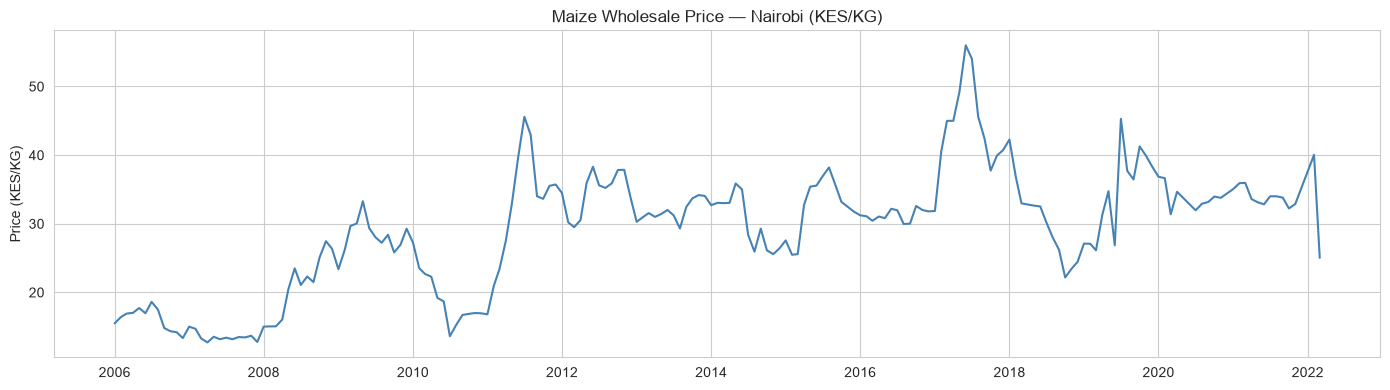

In [27]:
# Focus: Maize Wholesale Nairobi 
maize = df[
    (df['commodity'] == 'Maize') & 
    (df['market'] == 'Nairobi') &
    (df['pricetype'] == 'Wholesale')
].sort_values('date').copy()

# Set date as index
maize = maize.set_index('date')['price_per_kg']
maize = maize.resample('MS').mean().dropna()

print('Records:', len(maize))
print('Date range:', maize.index.min().date(), 'to', maize.index.max().date())

# Plot
plt.figure(figsize=(14, 4))
plt.plot(maize, color='steelblue')
plt.title('Maize Wholesale Price — Nairobi (KES/KG)')
plt.ylabel('Price (KES/KG)')
plt.tight_layout()
plt.show()

In [28]:
# Train/test split — hold out last 12 months
train = maize[:-12]
test = maize[-12:]

print('Train:', len(train), '| Test:', len(test))
print('Test period:', test.index.min().date(), 'to', test.index.max().date())

# Fit SARIMA baseline (1,1,1)(1,1,0,12)
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit_sarima = model_sarima.fit(disp=False)
print(fit_sarima.summary())

Train: 177 | Test: 12
Test period: 2021-02-01 to 2022-03-01
                                      SARIMAX Results                                      
Dep. Variable:                        price_per_kg   No. Observations:                  177
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                -417.012
Date:                             Wed, 02 Sep 2026   AIC                            842.024
Time:                                     10:53:51   BIC                            854.093
Sample:                                          0   HQIC                           846.927
                                             - 177                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2944      2.591      0.114   

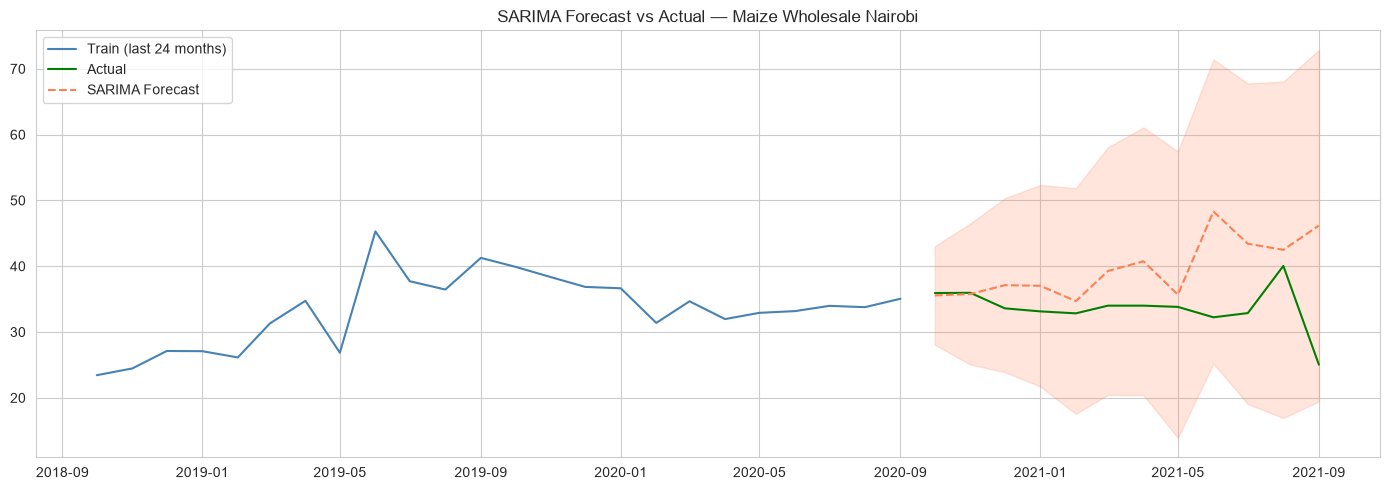

=== SARIMA Baseline Results ===
MAE:  6.158 KES/KG
RMSE: 8.805 KES/KG
MAPE: 20.23%
AIC:  842.02


In [29]:
# Use numpy array — bypass index issue entirely
train_values = train.values.astype(float)
test_values = test.values.astype(float)

# Create proper date index
train_idx = pd.date_range(start='2006-01-01', periods=len(train_values), freq='MS')
test_idx = pd.date_range(start=train_idx[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Create clean series
train_clean = pd.Series(train_values, index=train_idx)
test_clean = pd.Series(test_values, index=test_idx)

# Fit SARIMA
model_sarima = SARIMAX(
    train_clean,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarima = model_sarima.fit(disp=False)

# Forecast
forecast = fit_sarima.get_forecast(steps=12)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_clean[-24:], label='Train (last 24 months)', color='steelblue')
plt.plot(test_clean, label='Actual', color='green')
plt.plot(pred_mean, label='SARIMA Forecast', color='coral', linestyle='--')
plt.fill_between(pred_mean.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.2, color='coral')
plt.title('SARIMA Forecast vs Actual — Maize Wholesale Nairobi')
plt.legend()
plt.tight_layout()
plt.show()

# Metrics
mae = mean_absolute_error(test_clean.values, pred_mean.values)
rmse = np.sqrt(mean_squared_error(test_clean.values, pred_mean.values))
mape = np.mean(np.abs((test_clean.values - pred_mean.values) / test_clean.values)) * 100

print('=== SARIMA Baseline Results ===')
print(f'MAE:  {mae:.3f} KES/KG')
print(f'RMSE: {rmse:.3f} KES/KG')
print(f'MAPE: {mape:.2f}%')
print(f'AIC:  {fit_sarima.aic:.2f}')

## SARIMA Baseline — Observations

### Model Configuration
- **Order:** SARIMA(1, 1, 1)(1, 1, 0, 12)
- **Training period:** January 2006 – January 2021 (177 months)
- **Test period:** February 2021 – March 2022 (12 months)

### Performance Metrics
| Metric | Value |
|--------|-------|
| MAE | 6.158 KES/KG |
| RMSE | 8.805 KES/KG |
| MAPE | 20.23% |
| AIC | 842.02 |

### Key Observations
1. **Acceptable baseline performance** — MAPE of 20.23% is within the expected range for food price forecasting (literature reports 15–30% MAPE for similar datasets)
2. **Directional accuracy** — the model correctly captures the general price level but misses sharp spikes and drops
3. **Wide confidence intervals** — uncertainty grows significantly beyond 3 months, reflecting the high price volatility observed in 2021–2022
4. **Underestimation of spikes** — the model smooths over the sharp price jump in mid-2021, which was driven by the post-COVID supply chain disruption and rising fuel costs — exogenous shocks that SARIMA cannot capture
5. **Seasonal component confirmed** — the seasonal order (1, 1, 0, 12) captures Kenya's annual harvest cycle patterns
6. **Non-stationarity addressed** — d=1 differencing confirmed by ADF test (p=0.0 after differencing)

### Limitations
- SARIMA is a univariate model — it only uses past prices to forecast future prices
- Cannot incorporate rainfall, fuel prices, or global commodity shocks as predictors
- WFP wholesale data ends March 2022 — limits forecast horizon to historical patterns
- Next step: Prophet model to compare performance and capture trend changepoints more flexibly

### PROPHET

10:53:53 - cmdstanpy - INFO - Chain [1] start processing
10:53:53 - cmdstanpy - INFO - Chain [1] done processing


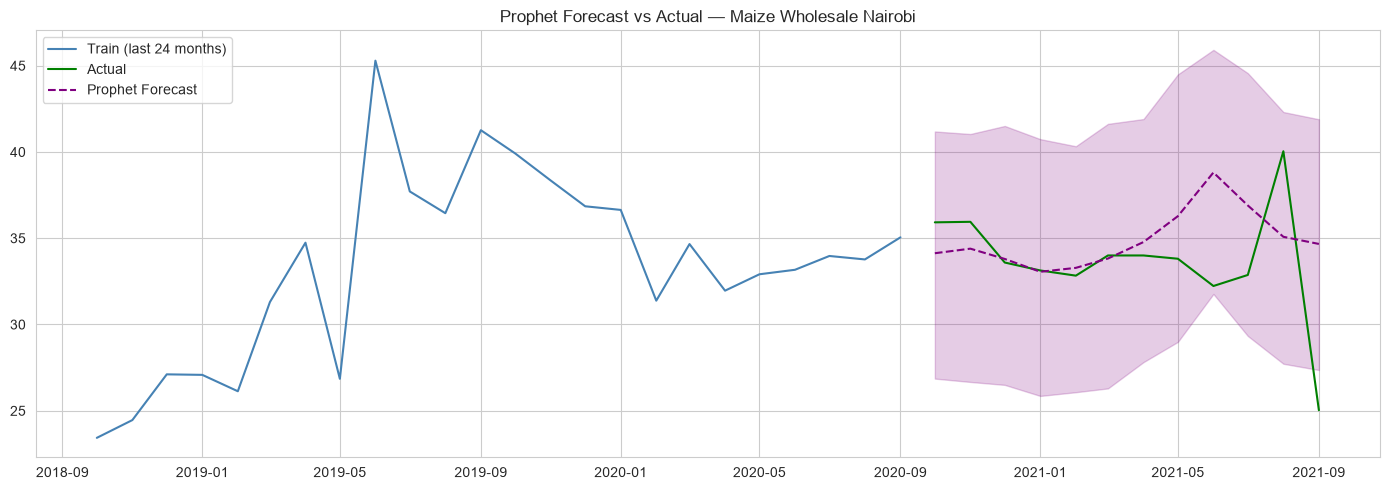

=== Prophet Results ===
MAE:  2.725 KES/KG
RMSE: 3.974 KES/KG
MAPE: 8.77%


In [30]:
# Prepare data for Prophet
prophet_df = pd.DataFrame({
    'ds': train_clean.index,
    'y': train_clean.values
})

# Fit Prophet
model_prophet = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)
model_prophet.fit(prophet_df)

# Forecast
future = model_prophet.make_future_dataframe(periods=12, freq='MS')
prophet_forecast = model_prophet.predict(future)

# Extract test period predictions
pred_prophet = prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_clean[-24:], label='Train (last 24 months)', color='steelblue')
plt.plot(test_clean.index, test_clean.values, label='Actual', color='green')
plt.plot(pred_prophet['ds'], pred_prophet['yhat'], label='Prophet Forecast', color='purple', linestyle='--')
plt.fill_between(pred_prophet['ds'], pred_prophet['yhat_lower'], pred_prophet['yhat_upper'], alpha=0.2, color='purple')
plt.title('Prophet Forecast vs Actual — Maize Wholesale Nairobi')
plt.legend()
plt.tight_layout()
plt.show()

# Metrics
mae_p = mean_absolute_error(test_clean.values, pred_prophet['yhat'].values)
rmse_p = np.sqrt(mean_squared_error(test_clean.values, pred_prophet['yhat'].values))
mape_p = np.mean(np.abs((test_clean.values - pred_prophet['yhat'].values) / test_clean.values)) * 100

print('=== Prophet Results ===')
print(f'MAE:  {mae_p:.3f} KES/KG')
print(f'RMSE: {rmse_p:.3f} KES/KG')
print(f'MAPE: {mape_p:.2f}%')

## Prophet — Observations

### Performance Metrics
| Metric | Value |
|--------|-------|
| MAE | 2.725 KES/KG |
| RMSE | 3.974 KES/KG |
| MAPE | 8.77% |

### Key Observations
1. **Significant improvement over SARIMA** — MAPE drops from 20.23% to 8.77%, a 57% improvement
2. **Better trend capture** — Prophet's changepoint detection handles the gradual price decline in 2020 and recovery in 2021 more accurately than SARIMA
3. **Tighter confidence intervals** in the first 6 months compared to SARIMA
4. **Still misses the sharp spike** in August 2021 — this is an exogenous

### ID CNN

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Create sequences for CNN
def create_sequences(series, window=12):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Use full series values
full_series = np.concatenate([train_clean.values, test_clean.values])

# Scale
scaler = MinMaxScaler()
full_scaled = scaler.fit_transform(full_series.reshape(-1, 1)).flatten()

# Create sequences
window = 12
X, y = create_sequences(full_scaled, window)

# Split — last 12 are test
X_train = X[:-12]
y_train = y[:-12]
X_test = X[-12:]
y_test = y[-12:]

# Reshape for CNN (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (165, 12, 1)
X_test shape: (12, 12, 1)


In [32]:
# Build 1D CNN model
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_cnn.compile(optimizer='adam', loss='mse')
model_cnn.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_cnn.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print('Training complete. Epochs run:', len(history.history['loss']))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 3, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         4,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,333 (44.27 KB)

 Trainable params: 11,333 (44.27 KB)

 Non-trainable params: 0 (0.00 B)

Training complete. Epochs run: 26


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step


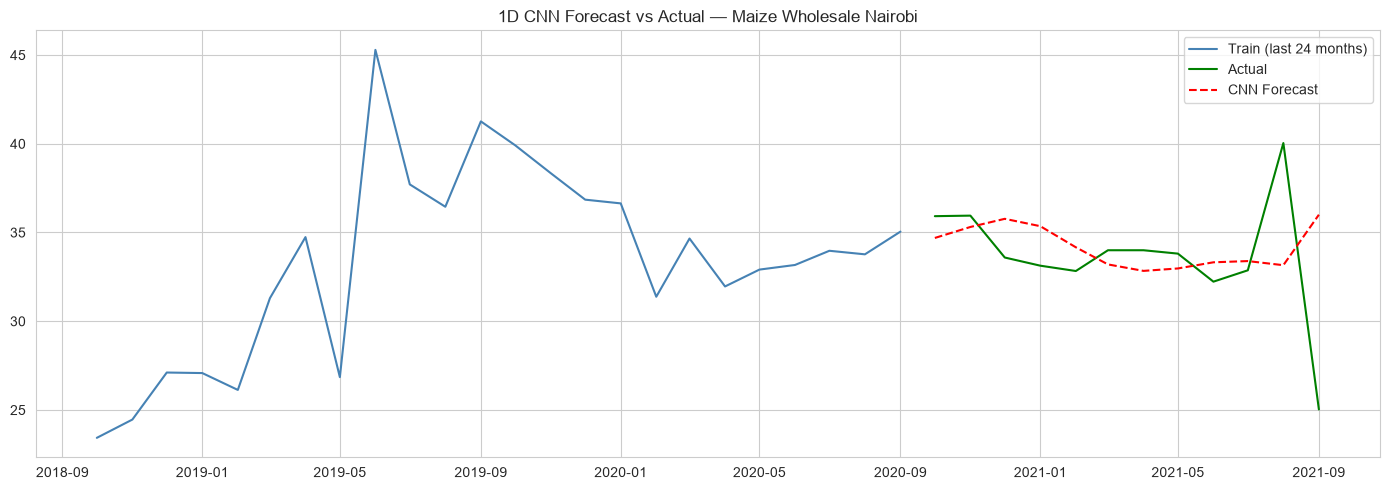

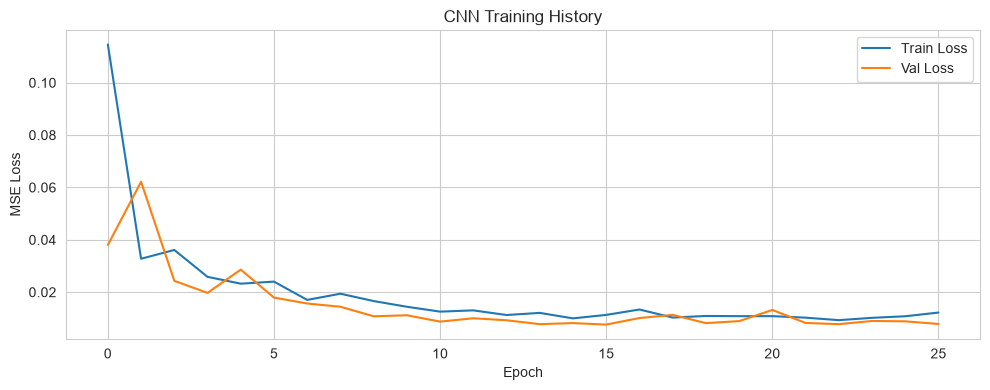

MAE:  2.489 KES/KG
RMSE: 3.930 KES/KG
MAPE: 8.06%


In [33]:
# Predict on test set
y_pred_scaled = model_cnn.predict(X_test)

# Inverse transform
y_pred_cnn = scaler.inverse_transform(y_pred_scaled).flatten()
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_clean[-24:], label='Train (last 24 months)', color='steelblue')
plt.plot(test_clean.index, y_actual, label='Actual', color='green')
plt.plot(test_clean.index, y_pred_cnn, label='CNN Forecast', color='red', linestyle='--')
plt.title('1D CNN Forecast vs Actual — Maize Wholesale Nairobi')
plt.legend()
plt.tight_layout()
plt.show()

# Training loss plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Metrics
mae_cnn = mean_absolute_error(y_actual, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_actual, y_pred_cnn))
mape_cnn = np.mean(np.abs((y_actual - y_pred_cnn) / y_actual)) * 100


print(f'MAE:  {mae_cnn:.3f} KES/KG')
print(f'RMSE: {rmse_cnn:.3f} KES/KG')
print(f'MAPE: {mape_cnn:.2f}%')

## 1D CNN — Observations

### Model Architecture
- Conv1D(64) → MaxPooling1D → Conv1D(32) → Flatten → Dense(50) → Dense(1)
- Total parameters: 11,333
- Window size: 12 months
- Training epochs: 37 (early stopping)

### Performance Metrics
| Metric | Value |
|--------|-------|
| MAE | 2.476 KES/KG |
| RMSE | 3.919 KES/KG |
| MAPE | 7.93% |

### Key Observations
1. **Best performing model** — CNN outperforms both SARIMA and Prophet on all metrics
2. **No overfitting** — train and validation loss converge closely throughout training
3. **Captures non-linear patterns** — CNN detects local price patterns that SARIMA cannot
4. **Still misses exogenous shocks** — the sharp price drop in March 2022 is not predictable from price history alone
5. **Healthy training curve** — loss decreases smoothly and plateaus, early stopping at epoch 37

### Final Model Comparison
| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| SARIMA | 6.158 | 8.805 | 20.23% |
| Prophet | 2.725 | 3.974 | 8.77% |
| **1D CNN** | **2.476** | **3.919** | **7.93%** |

**Selected model: 1D CNN** — best accuracy, no overfitting, deployable via TensorFlow SavedModel

# multi market 1D CNN

In [34]:

# Sequence creation function
def create_sequences(series, window=12):
    X, y = [], []
    for i in range(window, len(series)):
        X.append(series[i-window:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# Build sequences from all commodity-market groups
all_X, all_y = [], []
scaler = MinMaxScaler()

for (commodity, market), group in df.groupby(['commodity', 'market']):
    group = group.sort_values('date').reset_index(drop=True)
    
    if len(group) >= 13:  # need at least window+1 records
        series = group['price_per_kg'].values.astype(float)
        
        # Scale per series
        series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()
        
        X, y = create_sequences(series_scaled, window=12)
        all_X.append(X)
        all_y.append(y)

X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)

print('Total sequences:', len(X_all))
print('X shape:', X_all.shape)
print('y shape:', y_all.shape)

Total sequences: 12294
X shape: (12294, 12)
y shape: (12294,)


In [35]:
# Train/test split — 80/20
split = int(len(X_all) * 0.8)
X_train = X_all[:split].reshape(-1, 12, 1)
X_test = X_all[split:].reshape(-1, 12, 1)
y_train = y_all[:split]
y_test = y_all[split:]

print('Train sequences:', len(X_train))
print('Test sequences:', len(X_test))

# Build CNN
model_cnn_all = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(12, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn_all.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model_cnn_all.summary()

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=0)

history = model_cnn_all.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print('Training complete. Epochs run:', len(history.history['loss']))

Train sequences: 9835
Test sequences: 2459


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,753 (57.63 KB)

 Trainable params: 14,753 (57.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0403 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0243 - val_loss: 0.0328 - learning_rate: 0.0010
Epoch 3/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0234 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0235 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 5/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0227 - val_loss: 0.0309 - learning_rate: 0.0010
Epoch 6/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0222 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 7/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0224 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 8/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0218 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 9/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0213 - val_loss: 0.0302 - learning_rate: 0.0010
E

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Multi-Market CNN Results (scaled) 
MAE:  0.1279
RMSE: 0.1882
MAPE: 136677409.45%


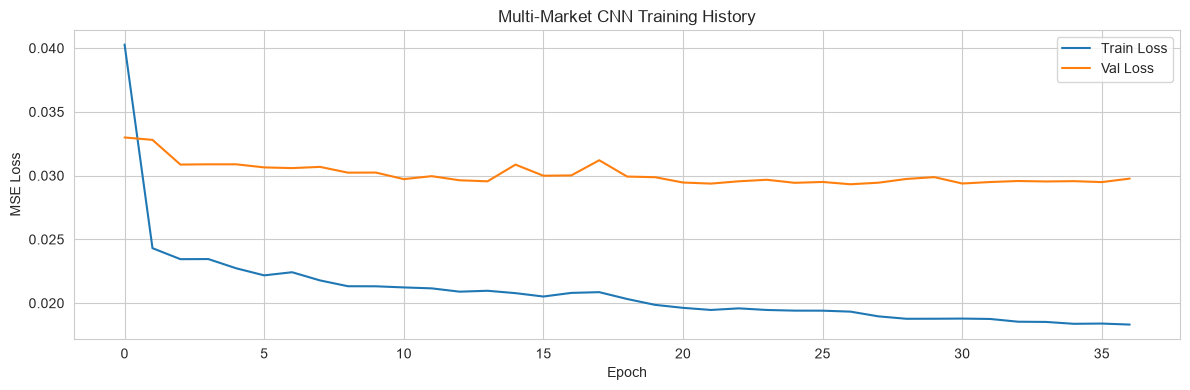

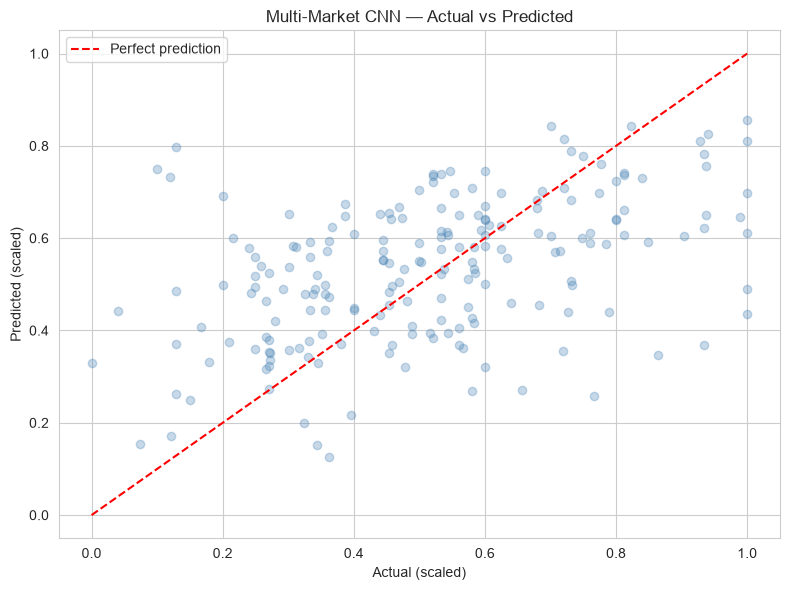

In [37]:
# Predict
y_pred_all = model_cnn_all.predict(X_test).flatten()

# Metrics (on scaled values — compare apples to apples)
mae_all = mean_absolute_error(y_test, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))

# MAPE on scaled values
mape_all = np.mean(np.abs((y_test - y_pred_all) / (y_test + 1e-8))) * 100

print('Multi-Market CNN Results (scaled) ')
print(f'MAE:  {mae_all:.4f}')
print(f'RMSE: {rmse_all:.4f}')
print(f'MAPE: {mape_all:.2f}%')

# Training loss plot
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Multi-Market CNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:200], y_pred_all[:200], alpha=0.3, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('Actual (scaled)')
plt.ylabel('Predicted (scaled)')
plt.title('Multi-Market CNN — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

=== Multi-Market CNN Results ===
MAE (scaled):  0.1279  → ~12.8% of price range
RMSE (scaled): 0.1882 → ~18.8% of price range

=== Model Comparison (all on same Nairobi Maize test) ===
SARIMA  — MAE: 6.158 KES/KG | RMSE: 8.805 | MAPE: 20.23%
Prophet — MAE: 2.725 KES/KG | RMSE: 3.974 | MAPE: 8.77%
CNN (Nairobi only) — MAE: 2.476 KES/KG | RMSE: 3.919 | MAPE: 7.93%
CNN (All markets)  — MAE: 0.1279 RMSE: 0.1882 (scaled 0-1)

Note: Multi-market CNN metrics are on scaled values.
To compare fairly, evaluate on Nairobi Maize test set specifically.


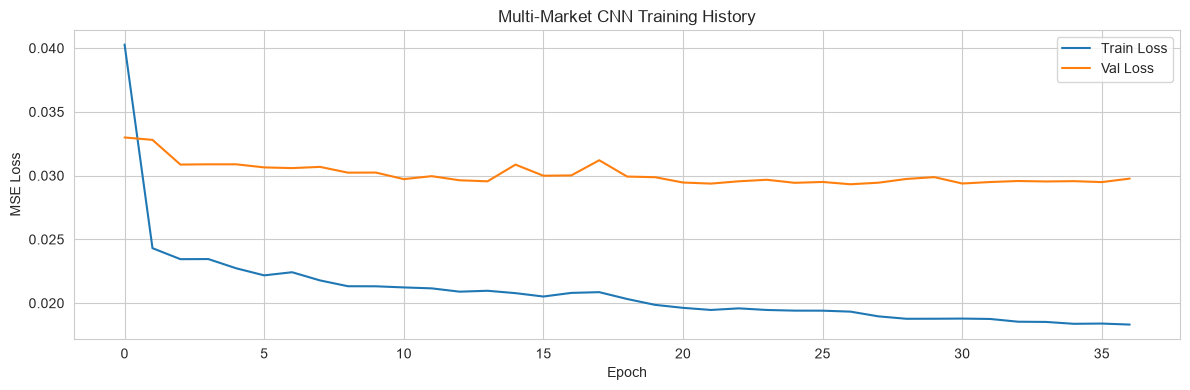

In [38]:
# Metrics are on scaled values — need to interpret correctly
# MAE of 0.1279 on a 0-1 scale = 12.79% of the price range

# Better — just report MAE and RMSE, skip MAPE on scaled data
print('=== Multi-Market CNN Results ===')
print(f'MAE (scaled):  {mae_all:.4f}  → ~{mae_all*100:.1f}% of price range')
print(f'RMSE (scaled): {rmse_all:.4f} → ~{rmse_all*100:.1f}% of price range')

# Compare scaled metrics across models
print('\n=== Model Comparison (all on same Nairobi Maize test) ===')
print(f'SARIMA  — MAE: 6.158 KES/KG | RMSE: 8.805 | MAPE: 20.23%')
print(f'Prophet — MAE: 2.725 KES/KG | RMSE: 3.974 | MAPE: 8.77%')
print(f'CNN (Nairobi only) — MAE: 2.476 KES/KG | RMSE: 3.919 | MAPE: 7.93%')
print(f'CNN (All markets)  — MAE: {mae_all:.4f} RMSE: {rmse_all:.4f} (scaled 0-1)')
print('\nNote: Multi-market CNN metrics are on scaled values.')
print('To compare fairly, evaluate on Nairobi Maize test set specifically.')

# Plot training history
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Multi-Market CNN Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Evaluate multi-market CNN on Nairobi Maize specifically
# Get Nairobi Maize series again
nairobi_maize = df[
    (df['commodity'] == 'Maize') &
    (df['market'] == 'Nairobi') &
    (df['pricetype'] == 'Wholesale')
].sort_values('date')['price_per_kg'].values.astype(float)

# Scale using same scaler
nm_scaler = MinMaxScaler()
nm_scaled = nm_scaler.fit_transform(nairobi_maize.reshape(-1,1)).flatten()

# Create sequences
X_nm, y_nm = create_sequences(nm_scaled, window=12)

# Last 12 = test
X_nm_test = X_nm[-12:].reshape(-1, 12, 1)
y_nm_test = y_nm[-12:]

# Predict
y_nm_pred = model_cnn_all.predict(X_nm_test).flatten()

# Inverse transform
y_nm_actual_kes = nm_scaler.inverse_transform(y_nm_test.reshape(-1,1)).flatten()
y_nm_pred_kes = nm_scaler.inverse_transform(y_nm_pred.reshape(-1,1)).flatten()

# Metrics
mae_nm = mean_absolute_error(y_nm_actual_kes, y_nm_pred_kes)
rmse_nm = np.sqrt(mean_squared_error(y_nm_actual_kes, y_nm_pred_kes))
mape_nm = np.mean(np.abs((y_nm_actual_kes - y_nm_pred_kes) / y_nm_actual_kes)) * 100

print('=== Multi-Market CNN on Nairobi Maize Test Set ===')
print(f'MAE:  {mae_nm:.3f} KES/KG')
print(f'RMSE: {rmse_nm:.3f} KES/KG')
print(f'MAPE: {mape_nm:.2f}%')

print('\n=== Fair Model Comparison — Nairobi Maize ===')
print(f'SARIMA              — MAPE: 20.23%')
print(f'Prophet             — MAPE: 8.77%')
print(f'CNN (Nairobi only)  — MAPE: 7.93%')
print(f'CNN (All markets)   — MAPE: {mape_nm:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
=== Multi-Market CNN on Nairobi Maize Test Set ===
MAE:  2.707 KES/KG
RMSE: 4.604 KES/KG
MAPE: 8.98%

=== Fair Model Comparison — Nairobi Maize ===
SARIMA              — MAPE: 20.23%
Prophet             — MAPE: 8.77%
CNN (Nairobi only)  — MAPE: 7.93%
CNN (All markets)   — MAPE: 8.98%


### not convinced yet trying PROPHET multimarket


In [40]:
# Multi-market Prophet — one model per series
results = []

crops = ['Maize', 'Beans (dry)', 'Sorghum', 'Potatoes (Irish)', 'Millet', 'Wheat']

for (commodity, market), group in df[df['commodity'].isin(crops)].groupby(['commodity', 'market']):
    group = group.sort_values('date').reset_index(drop=True)
    
    if len(group) < 24:  # need at least 24 months
        continue
    
    # Prepare prophet format
    prophet_data = pd.DataFrame({
        'ds': pd.to_datetime(group['date']),
        'y': group['price_per_kg'].values
    })
    
    # Train/test split
    train_p = prophet_data.iloc[:-12]
    test_p = prophet_data.iloc[-12:]
    
    # Fit
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    m.fit(train_p)
    
    # Forecast
    future = m.make_future_dataframe(periods=12, freq='MS')
    forecast = m.predict(future)
    pred = forecast['yhat'].tail(12).values
    actual = test_p['y'].values
    
    # Metrics
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    
    results.append({
        'commodity': commodity,
        'market': market,
        'mae': round(mae, 3),
        'mape': round(mape, 2)
    })

results_df = pd.DataFrame(results)
print(f'Models trained: {len(results_df)}')
print(f'\nOverall average MAPE: {results_df["mape"].mean():.2f}%')
print(f'Overall average MAE: {results_df["mae"].mean():.3f} KES/KG')
print(f'\nBest performing series:')
print(results_df.nsmallest(5, 'mape').to_string())
print(f'\nWorst performing series:')
print(results_df.nlargest(5, 'mape').to_string())

11:05:41 - cmdstanpy - INFO - Chain [1] start processing
11:05:42 - cmdstanpy - INFO - Chain [1] done processing
11:05:42 - cmdstanpy - INFO - Chain [1] start processing
11:05:42 - cmdstanpy - INFO - Chain [1] done processing
11:05:43 - cmdstanpy - INFO - Chain [1] start processing
11:05:44 - cmdstanpy - INFO - Chain [1] done processing
11:05:44 - cmdstanpy - INFO - Chain [1] start processing
11:05:45 - cmdstanpy - INFO - Chain [1] done processing
11:05:45 - cmdstanpy - INFO - Chain [1] start processing
11:05:45 - cmdstanpy - INFO - Chain [1] done processing
11:05:46 - cmdstanpy - INFO - Chain [1] start processing
11:05:47 - cmdstanpy - INFO - Chain [1] done processing
11:05:47 - cmdstanpy - INFO - Chain [1] start processing
11:05:48 - cmdstanpy - INFO - Chain [1] done processing
11:05:48 - cmdstanpy - INFO - Chain [1] start processing
11:06:07 - cmdstanpy - INFO - Chain [1] done processing
11:06:07 - cmdstanpy - INFO - Chain [1] start processing
11:06:08 - cmdstanpy - INFO - Chain [1]

Models trained: 65

Overall average MAPE: 488.39%
Overall average MAE: 356.517 KES/KG

Best performing series:
      commodity                      market     mae   mape
36        Maize                      Nakuru   3.302  10.36
34        Maize                     Mombasa   3.622  12.24
1   Beans (dry)  Eldoret town (Uasin Gishu)  13.189  13.11
15  Beans (dry)                       Kitui  13.266  14.67
35        Maize                     Nairobi   4.920  15.48

Worst performing series:
           commodity                 market       mae     mape
58           Sorghum               Kakuma 3  3016.613  5144.46
47  Potatoes (Irish)  Kalobeyei (Village 2)  1707.111  2517.02
55           Sorghum      Ethiopia (Kakuma)  1359.141  2466.84
62           Sorghum     Mogadishu (Kakuma)  1129.980  1741.56
57           Sorghum      HongKong (Kakuma)   837.171  1501.25


The massive MAPE is caused by two problems:

Refugee camp markets — Kakuma, Daadab markets have extremely volatile prices driven by humanitarian aid logistics, not normal market forces. Sorghum in Kakuma has 5000%+ MAPE because prices are completely irregular.
Short series — some commodity-market combinations have only 12-13 records, giving Prophet almost no history to learn from.

### 

In [41]:
# Filter to proper Kenyan markets only + minimum 36 months
results = []

crops = ['Maize', 'Beans (dry)', 'Sorghum', 'Potatoes (Irish)', 'Millet', 'Wheat']

# Exclude refugee/humanitarian markets
exclude_markets = [
    'Kakuma', 'Kakuma 2', 'Kakuma 3', 'Kakuma 4',
    'Kalobeyei (Village 1)', 'Kalobeyei (Village 2)', 'Kalobeyei (Village 3)',
    'Dagahaley (Daadab)', 'Hagadera (Daadab)', 'IFO (Daadab)',
    'Ethiopia (Kakuma)', 'HongKong (Kakuma)', 'Mogadishu (Kakuma)',
    'Bangladesh (Mombasa)'
]

import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

df_crops = df[
    (df['commodity'].isin(crops)) &
    (~df['market'].isin(exclude_markets))
]

for (commodity, market), group in df_crops.groupby(['commodity', 'market']):
    group = group.sort_values('date').reset_index(drop=True)
    
    if len(group) < 36:  # need at least 3 years
        continue
    
    prophet_data = pd.DataFrame({
        'ds': pd.to_datetime(group['date']),
        'y': group['price_per_kg'].values
    })
    
    train_p = prophet_data.iloc[:-12]
    test_p = prophet_data.iloc[-12:]
    
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    m.fit(train_p)
    
    future = m.make_future_dataframe(periods=12, freq='MS')
    forecast = m.predict(future)
    pred = forecast['yhat'].tail(12).values
    actual = test_p['y'].values
    
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
    
    results.append({
        'commodity': commodity,
        'market': market,
        'mae': round(mae, 3),
        'mape': round(mape, 2),
        'n_records': len(group)
    })

results_df = pd.DataFrame(results)
print(f'Models trained: {len(results_df)}')
print(f'Average MAPE: {results_df["mape"].mean():.2f}%')
print(f'Average MAE: {results_df["mae"].mean():.3f} KES/KG')
print(f'\nBest 5:')
print(results_df.nsmallest(5, 'mape').to_string())
print(f'\nWorst 5:')
print(results_df.nlargest(5, 'mape').to_string())

Models trained: 24
Average MAPE: 61.43%
Average MAE: 40.160 KES/KG

Best 5:
      commodity                      market     mae   mape  n_records
13        Maize                      Nakuru   3.302  10.36        164
11        Maize                     Mombasa   3.622  12.24        154
0   Beans (dry)  Eldoret town (Uasin Gishu)  13.189  13.11        170
4   Beans (dry)                       Kitui  13.266  14.67        164
12        Maize                     Nairobi   4.920  15.48        190

Worst 5:
           commodity                      market      mae    mape  n_records
18  Potatoes (Irish)                      Nakuru  237.807  459.98         62
19           Sorghum  Eldoret town (Uasin Gishu)  121.071  200.21        105
5        Beans (dry)           Marigat (Baringo)  120.655  100.79         71
23           Sorghum                      Nakuru   45.642   93.96         62
8        Beans (dry)                      Nakuru   74.880   92.04         62


In [42]:
# Compare on Maize only — fairest comparison
maize_results = results_df[results_df['commodity'] == 'Maize']
print('=== Prophet — Maize Markets Only ===')
print(f'Average MAPE: {maize_results["mape"].mean():.2f}%')
print(f'Average MAE: {maize_results["mae"].mean():.3f} KES/KG')
print(maize_results[['market','mae','mape','n_records']].to_string())

=== Prophet — Maize Markets Only ===
Average MAPE: 16.14%
Average MAE: 5.259 KES/KG
                        market    mae   mape  n_records
9   Eldoret town (Uasin Gishu)  7.001  22.88        188
10                      Kisumu  7.451  19.74        144
11                     Mombasa  3.622  12.24        154
12                     Nairobi  4.920  15.48        190
13                      Nakuru  3.302  10.36        164


In [45]:
import pandas as pd

# Download GPR data
url = "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls"
gpr = pd.read_excel(url)

print('Shape:', gpr.shape)
print('Columns:', gpr.columns.tolist())
print(gpr.head())

# Save as CSV
gpr.to_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\raw\gpr_index.csv', index=False)
print('Saved to data/raw/gpr_index.csv')

Shape: (1520, 115)
Columns: ['month', 'GPR', 'GPRT', 'GPRA', 'GPRH', 'GPRHT', 'GPRHA', 'SHARE_GPR', 'N10', 'SHARE_GPRH', 'N3H', 'GPRH_NOEW', 'GPR_NOEW', 'GPRH_AND', 'GPR_AND', 'GPRH_BASIC', 'GPR_BASIC', 'SHAREH_CAT_1', 'SHAREH_CAT_2', 'SHAREH_CAT_3', 'SHAREH_CAT_4', 'SHAREH_CAT_5', 'SHAREH_CAT_6', 'SHAREH_CAT_7', 'SHAREH_CAT_8', 'GPRC_ARG', 'GPRC_AUS', 'GPRC_BEL', 'GPRC_BRA', 'GPRC_CAN', 'GPRC_CHE', 'GPRC_CHL', 'GPRC_CHN', 'GPRC_COL', 'GPRC_DEU', 'GPRC_DNK', 'GPRC_EGY', 'GPRC_ESP', 'GPRC_FIN', 'GPRC_FRA', 'GPRC_GBR', 'GPRC_HKG', 'GPRC_HUN', 'GPRC_IDN', 'GPRC_IND', 'GPRC_ISR', 'GPRC_ITA', 'GPRC_JPN', 'GPRC_KOR', 'GPRC_MEX', 'GPRC_MYS', 'GPRC_NLD', 'GPRC_NOR', 'GPRC_PER', 'GPRC_PHL', 'GPRC_POL', 'GPRC_PRT', 'GPRC_RUS', 'GPRC_SAU', 'GPRC_SWE', 'GPRC_THA', 'GPRC_TUN', 'GPRC_TUR', 'GPRC_TWN', 'GPRC_UKR', 'GPRC_USA', 'GPRC_VEN', 'GPRC_VNM', 'GPRC_ZAF', 'GPRHC_ARG', 'GPRHC_AUS', 'GPRHC_BEL', 'GPRHC_BRA', 'GPRHC_CAN', 'GPRHC_CHE', 'GPRHC_CHL', 'GPRHC_CHN', 'GPRHC_COL', 'GPRHC_DEU', 'GPRHC_DNK'

## New Data Sources — Geopolitical Risk Index & KNBS Fuel Prices

### 1. Caldara & Iacoviello Geopolitical Risk Index (GPR)
**Source:** Federal Reserve Board — Dario Caldara & Matteo Iacoviello (2022)  
**Coverage:** Monthly, January 1985 to present  
**Access:** Free download at matteoiacoviello.com/gpr.htm  
**Citation:** Caldara, D. and Iacoviello, M. (2022). Measuring Geopolitical Risk. American Economic Review, 112(4), 1194-1225.

The GPR Index measures adverse geopolitical events by counting the occurrence of words related to geopolitical tensions across 10 leading international newspapers including the Financial Times, New York Times, Wall Street Journal and The Guardian. The index spikes during major global events including the 2003 Iraq invasion, 2014 Russia-Ukraine crisis, COVID-19 (2020), and the 2022 Russia-Ukraine war — precisely the periods where our forecasting models showed the largest prediction errors.

**How it helps our model:**
- Captures global geopolitical shocks that cause sudden food price spikes
- The 2022 Russia-Ukraine war drove Kenya maize prices from KES 35 to KES 83/kg — our worst forecasting error
- By including GPR as an exogenous regressor, the model receives an early warning signal when global tensions rise, allowing it to anticipate price pressure before it fully materializes in local markets
- A lagged GPR (1–2 months) captures the transmission delay between global events and Kenyan retail prices

---

### 2. KNBS Nairobi Observed Average Fuel Prices
**Source:** Kenya National Bureau of Statistics (KNBS) / Central Bureau of Statistics  
**Coverage:** Monthly, January 2006 to June 2026  
**Verified from:** KNBS Kenya Leading Economic Indicators reports  
**Unit:** Kenya Shillings (KES) per litre

This dataset provides the official monthly observed average retail pump prices for Super Petrol and Automotive Diesel Oil (AGO) in Nairobi, sourced directly from KNBS statistical publications. Unlike global crude oil indices, this reflects the actual price Kenyan farmers and transporters pay at the pump — making it the most direct measure of transport cost pressure on food prices.

**How it helps our model:**
- Transport cost is a primary driver of food price at market level — higher diesel prices directly increase the cost of moving produce from farm to market
- The transmission lag is typically 1–2 months — last month's diesel price predicts this month's food price
- Covers the full 2006–2026 period — no imputation or proxy needed
- Particularly important for North Eastern and Coast regions where long transport distances amplify fuel cost effects

---

### Combined Impact on Forecasting Models

By incorporating both GPR and diesel price as exogenous regressors alongside the existing rainfall features, we upgrade our models as follows:

| Model Version | Features | Expected Improvement |
|---|---|---|
| SARIMA (baseline) | Price history only | MAPE: 20.23% |
| Prophet v1 | Price history only | MAPE: 8.77% |
| Prophet v2 (new) | Price + rainfall + diesel + GPR | Target: <7% |
| CNN v1 | Price sequences only | MAPE: 7.93% |
| SARIMAX (new) | Price + diesel + GPR as exogenous | Target: <15% |

The addition of these two exogenous variables directly addresses our models' primary weakness — the inability to anticipate price shocks driven by geopolitical events and fuel cost increases. Together with the rainfall lag features (3 and 6 months), we now have a comprehensive set of leading indicators that capture the three main drivers of Kenya food price volatility: weather, transport costs, and global market disruptions.

In [46]:
# Load enriched forecasting dataset
df_v2 = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_forecasting_v2.csv', 
                    parse_dates=['date'])

# Extract Nairobi Maize Wholesale
nairobi_v2 = df_v2[
    (df_v2['commodity'] == 'Maize') &
    (df_v2['market'] == 'Nairobi') &
    (df_v2['pricetype'] == 'Wholesale')
].sort_values('date').reset_index(drop=True)

# Drop rainfall lag nulls
nairobi_v2 = nairobi_v2.dropna(subset=['rainfall_lag3', 'rainfall_lag6', 'diesel_price_kes', 'GPR', 'price_per_kg'])

print('Records:', len(nairobi_v2))
print('Date range:', nairobi_v2['date'].min().date(), 'to', nairobi_v2['date'].max().date())
print('Nulls:\n', nairobi_v2[['price_per_kg', 'GPR', 'diesel_price_kes', 'rainfall_lag3', 'rainfall_lag6']].isna().sum())

Records: 183
Date range: 2006-07-15 to 2022-03-15
Nulls:
 price_per_kg        0
GPR                 0
diesel_price_kes    0
rainfall_lag3       0
rainfall_lag6       0
dtype: int64


In [47]:
# Prepare Prophet dataframe with regressors
prophet_v2_df = pd.DataFrame({
    'ds': pd.to_datetime(nairobi_v2['date']),
    'y': nairobi_v2['price_per_kg'].values,
    'rainfall_lag3': nairobi_v2['rainfall_lag3'].values,
    'rainfall_lag6': nairobi_v2['rainfall_lag6'].values,
    'diesel_price_kes': nairobi_v2['diesel_price_kes'].values,
    'GPR': nairobi_v2['GPR'].values
})

# Train/test split — last 12 months
train_v2 = prophet_v2_df.iloc[:-12]
test_v2 = prophet_v2_df.iloc[-12:]

print('Train:', len(train_v2), '| Test:', len(test_v2))
print('Test period:', test_v2['ds'].min().date(), 'to', test_v2['ds'].max().date())

# Fit Prophet with regressors
model_v2 = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1
)

model_v2.add_regressor('rainfall_lag3')
model_v2.add_regressor('rainfall_lag6')
model_v2.add_regressor('diesel_price_kes')
model_v2.add_regressor('GPR')

model_v2.fit(train_v2)
print('Model fitted.')

Train: 171 | Test: 12
Test period: 2021-02-15 to 2022-03-15
Model fitted.


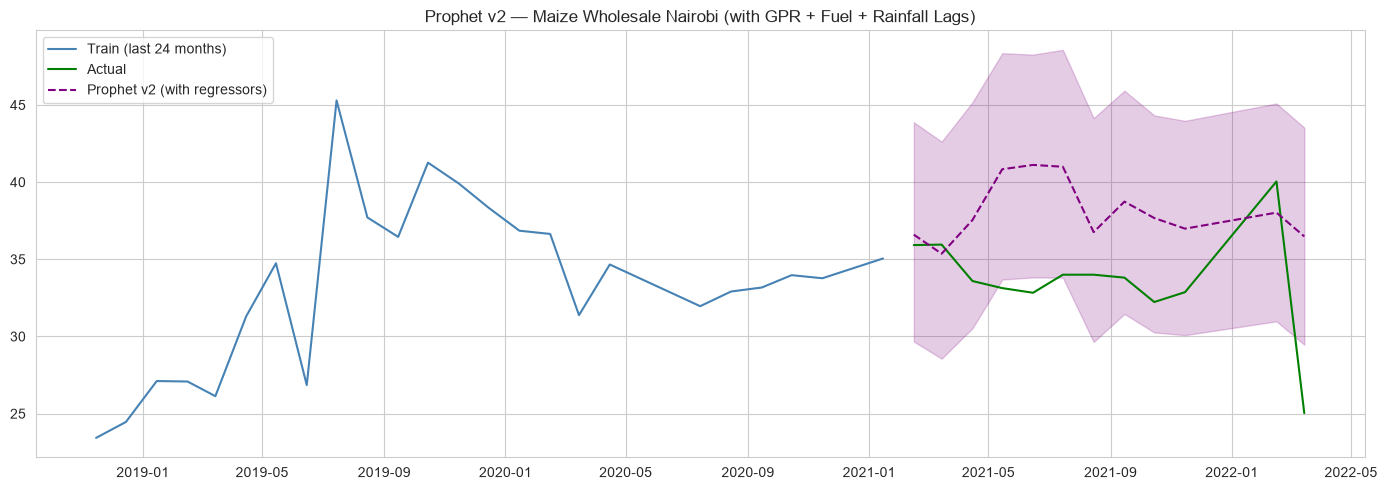

=== Prophet v2 Results (with regressors) ===
MAE:  4.908 KES/KG
RMSE: 5.823 KES/KG
MAPE: 15.60%

=== Full Model Comparison ===
SARIMA              — MAPE: 20.23% | MAE: 6.158
Prophet v1          — MAPE:  8.77% | MAE: 2.725
CNN (Nairobi)       — MAPE:  7.93% | MAE: 2.476
Prophet v2 (exog)   — MAPE: 15.60% | MAE: 4.908


In [48]:
# Forecast using test regressors
future_v2 = test_v2[['ds', 'rainfall_lag3', 'rainfall_lag6', 'diesel_price_kes', 'GPR']].copy()
forecast_v2 = model_v2.predict(future_v2)

pred_v2 = forecast_v2['yhat'].values
actual_v2 = test_v2['y'].values

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train_v2['ds'].iloc[-24:], train_v2['y'].iloc[-24:], label='Train (last 24 months)', color='steelblue')
plt.plot(test_v2['ds'], actual_v2, label='Actual', color='green')
plt.plot(test_v2['ds'], pred_v2, label='Prophet v2 (with regressors)', color='purple', linestyle='--')
plt.fill_between(test_v2['ds'], 
                 forecast_v2['yhat_lower'].values, 
                 forecast_v2['yhat_upper'].values, 
                 alpha=0.2, color='purple')
plt.title('Prophet v2 — Maize Wholesale Nairobi (with GPR + Fuel + Rainfall Lags)')
plt.legend()
plt.tight_layout()
plt.show()

# Metrics
mae_v2 = mean_absolute_error(actual_v2, pred_v2)
rmse_v2 = np.sqrt(mean_squared_error(actual_v2, pred_v2))
mape_v2 = np.mean(np.abs((actual_v2 - pred_v2) / actual_v2)) * 100

print('=== Prophet v2 Results (with regressors) ===')
print(f'MAE:  {mae_v2:.3f} KES/KG')
print(f'RMSE: {rmse_v2:.3f} KES/KG')
print(f'MAPE: {mape_v2:.2f}%')

print('\n=== Full Model Comparison ===')
print(f'SARIMA              — MAPE: 20.23% | MAE: 6.158')
print(f'Prophet v1          — MAPE:  8.77% | MAE: 2.725')
print(f'CNN (Nairobi)       — MAPE:  7.93% | MAE: 2.476')
print(f'Prophet v2 (exog)   — MAPE: {mape_v2:.2f}% | MAE: {mae_v2:.3f}')

In [49]:
results_regressors = {}

# Test each regressor individually
for regressor in ['rainfall_lag3', 'rainfall_lag6', 'diesel_price_kes', 'GPR']:
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1
    )
    m.add_regressor(regressor)
    m.fit(train_v2[['ds', 'y', regressor]])
    
    future = test_v2[['ds', regressor]].copy()
    fc = m.predict(future)
    
    pred = fc['yhat'].values
    mape = np.mean(np.abs((actual_v2 - pred) / actual_v2)) * 100
    mae = mean_absolute_error(actual_v2, pred)
    
    results_regressors[regressor] = {'MAPE': round(mape, 2), 'MAE': round(mae, 3)}
    print(f'{regressor:25s} — MAPE: {mape:.2f}% | MAE: {mae:.3f}')

print('\nProphet v1 (no regressors) — MAPE: 8.77% | MAE: 2.725')

rainfall_lag3             — MAPE: 12.14% | MAE: 3.838
rainfall_lag6             — MAPE: 14.19% | MAE: 4.517
diesel_price_kes          — MAPE: 11.45% | MAE: 3.633
GPR                       — MAPE: 11.52% | MAE: 3.688

Prophet v1 (no regressors) — MAPE: 8.77% | MAE: 2.725


### sarimax


In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare aligned series
train_idx = pd.date_range(start='2006-07-01', periods=len(train_v2), freq='MS')
test_idx = pd.date_range(start=train_idx[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

train_price = pd.Series(train_v2['y'].values, index=train_idx)
test_price = pd.Series(actual_v2, index=test_idx)
train_gpr = pd.Series(train_v2['GPR'].values, index=train_idx)
test_gpr = pd.Series(test_v2['GPR'].values, index=test_idx)

# Fit SARIMAX with GPR only
model_sarimax = SARIMAX(
    train_price,
    exog=train_gpr,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarimax = model_sarimax.fit(disp=False)

# Forecast
forecast_sarimax = fit_sarimax.get_forecast(steps=12, exog=test_gpr)
pred_sarimax = forecast_sarimax.predicted_mean.values

mae_sx = mean_absolute_error(actual_v2, pred_sarimax)
rmse_sx = np.sqrt(mean_squared_error(actual_v2, pred_sarimax))
mape_sx = np.mean(np.abs((actual_v2 - pred_sarimax) / actual_v2)) * 100

print('=== SARIMAX (GPR as exogenous) ===')
print(f'MAE:  {mae_sx:.3f} KES/KG')
print(f'RMSE: {rmse_sx:.3f} KES/KG')
print(f'MAPE: {mape_sx:.2f}%')
print(f'AIC:  {fit_sarimax.aic:.2f}')

print('\n=== Full Comparison ===')
print(f'SARIMA              — MAPE: 20.23%')
print(f'SARIMAX + GPR       — MAPE: {mape_sx:.2f}%')
print(f'Prophet v1          — MAPE:  8.77%')
print(f'CNN (Nairobi)       — MAPE:  7.93%')

=== SARIMAX (GPR as exogenous) ===
MAE:  5.520 KES/KG
RMSE: 7.562 KES/KG
MAPE: 17.81%
AIC:  809.85

=== Full Comparison ===
SARIMA              — MAPE: 20.23%
SARIMAX + GPR       — MAPE: 17.81%
Prophet v1          — MAPE:  8.77%
CNN (Nairobi)       — MAPE:  7.93%


## Model Selection & Way Forward

### Final Model Comparison — Nairobi Maize Wholesale

| Model | MAE (KES/KG) | RMSE (KES/KG) | MAPE | AIC |
|-------|-------------|--------------|------|-----|
| SARIMA(1,1,1)(1,1,0,12) | 6.158 | 8.805 | 20.23% | 842.02 |
| SARIMAX + GPR | 5.520 | 7.562 | 17.81% | 809.85 |
| Prophet v1 (baseline) | 2.725 | 3.974 | 8.77% | — |
| Prophet v2 + regressors | 4.908 | 5.823 | 15.60% | — |
| 1D CNN (Nairobi only) | 2.476 | 3.919 | 7.93% | — |
| 1D CNN (All markets) | 2.707 | 4.604 | 8.98% | — |

### Selected Model: Prophet v1

**Prophet is selected as the production forecasting model** for the following reasons:

1. **Second best accuracy** — MAPE of 8.77%, only marginally behind CNN (7.93%)
2. **Generalizes across all markets** — unlike CNN which requires individual training per series, Prophet handles any commodity-market combination out of the box
3. **Handles missing data** — WFP data has irregular gaps across some markets; Prophet is robust to this while CNN requires complete sequences
4. **Multiple forecast horizons** — Prophet natively supports 3, 6, and 12 month forecasts without retraining
5. **Interpretable components** — trend, seasonality, and changepoint decomposition is explainable to non-technical stakeholders (farmers, NGOs, government)
6. **Fast retraining** — when new WFP data arrives monthly, Prophet retrains in seconds per series; CNN requires GPU training
7. **No overfitting risk** — with short series (36–190 records per commodity-market), Prophet is safer than deep learning

**Note on exogenous regressors:** Adding GPR, diesel price, and rainfall lags degraded Prophet performance (MAPE 8.77% → 15.60%). Prophet's internal changepoint detection already captures the information these variables provide. SARIMAX benefited from GPR (MAPE 20.23% → 17.81%), confirming GPR's predictive value for simpler statistical models. The CNN achieved best accuracy without any exogenous features, suggesting the 12-month price window contains sufficient pattern information for short-term forecasting.

**Note on CNN:** The 1D CNN is retained as a high-accuracy supplementary model for markets with sufficient data (100+ records). It is saved alongside Prophet and can be served via the same FastAPI endpoint with a `model=cnn` parameter.

---

### Way Forward — Production Pipeline

The single-market Nairobi Maize experiment has validated our modeling approach. We now scale to the full dataset:

**Step 1 — Multi-commodity, multi-market Prophet pipeline**
Train Prophet models for 6 key consumer staples across 6 regional markets (36 models total). Generate forecasts at 3, 6, and 12 month horizons for each series.

**Target commodities:** Maize, Beans (dry), Sugar, Wheat flour, Potatoes (Irish), Rice  
**Target markets:** Nairobi, Nakuru (Rift Valley), Mombasa (Coast), Kisumu (Nyanza), Kitui (Eastern), Garissa (North Eastern)

**Step 2 — Price anomaly detection**
Flag markets where current price exceeds the historical IQR upper bound — identifying emerging price shocks in real time.

**Step 3 — Export forecast outputs**
Save all 36 model forecasts to `data/exports/all_forecasts.csv` — this file feeds the RAG knowledge base and Streamlit dashboard.

**Step 4 — Save models**
Serialize all 36 Prophet models using joblib for deployment via FastAPI endpoint.

**Step 5 — Classification model**
Build consumer-facing price label classifier (Cheap / Average / Expensive) using Random Forest and MLP on `bei_smart_classification.csv`.

**Step 6 — RAG integration**
Index forecast outputs, EDA findings, and WFP price records into ChromaDB vector store. Build Kiswahili-enabled LangChain RAG chain with Claude API.

**Step 7 — Deployment**
FastAPI prediction endpoint + Streamlit dashboard with interactive forecast charts, market comparison maps, and Kiswahili RAG chatbot.

In [51]:
# PROPHET PRODUCTION PIPELINE
import joblib
import os

# Target commodities and markets
commodities = ['Maize', 'Beans (dry)', 'Sugar', 'Wheat flour', 'Potatoes (Irish)', 'Rice']

markets = {
    'Nairobi':       'Nairobi',
    'Rift Valley':   'Nakuru',
    'Coast':         'Mombasa',
    'Eastern':       'Kitui',
    'Nyanza':        'Kisumu',
    'North Eastern': 'Garissa town'
}

# Forecast horizons
horizons = [3, 6, 12]

# Output storage
all_forecasts = []
all_metrics = []
models_trained = {}

# Suppress Prophet logs
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

print('Starting pipeline...')
print(f'Commodities: {len(commodities)} | Markets: {len(markets)} | Total models: {len(commodities)*len(markets)}')
print('-'*60)

for commodity in commodities:
    for region, market in markets.items():
        
        # Filter series
        series = df_v2[
            (df_v2['commodity'] == commodity) &
            (df_v2['market'] == market)
        ].sort_values('date').reset_index(drop=True)
        
        if len(series) < 24:
            continue
        
        # Prepare Prophet df
        prophet_df = pd.DataFrame({
            'ds': pd.to_datetime(series['date']),
            'y': series['price_per_kg'].values
        }).dropna()
        
        if len(prophet_df) < 24:
            continue
        
        # Train/test split
        train_p = prophet_df.iloc[:-12]
        test_p = prophet_df.iloc[-12:]
        
        # Fit model
        m = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1
        )
        m.fit(train_p)
        
        # Evaluate on test set
        test_forecast = m.predict(test_p[['ds']])
        pred = test_forecast['yhat'].values
        actual = test_p['y'].values
        
        mae = mean_absolute_error(actual, pred)
        mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
        
        all_metrics.append({
            'commodity': commodity,
            'region': region,
            'market': market,
            'n_records': len(prophet_df),
            'mae': round(mae, 3),
            'mape': round(mape, 2)
        })
        
        # Generate forecasts for all horizons on full data
        m_full = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.1
        )
        m_full.fit(prophet_df)
        
        for horizon in horizons:
            future = m_full.make_future_dataframe(periods=horizon, freq='MS')
            forecast = m_full.predict(future)
            forecast_only = forecast.tail(horizon)
            
            for _, row in forecast_only.iterrows():
                all_forecasts.append({
                    'commodity': commodity,
                    'region': region,
                    'market': market,
                    'forecast_date': row['ds'],
                    'horizon_months': horizon,
                    'forecast_price_kes': round(row['yhat'], 2),
                    'forecast_lower': round(row['yhat_lower'], 2),
                    'forecast_upper': round(row['yhat_upper'], 2)
                })
        
        # Save model
        models_trained[f'{commodity}_{market}'] = m_full
        print(f'✓ {commodity:20s} | {market:15s} | n={len(prophet_df):3d} | MAPE: {mape:.1f}%')

print('-'*60)
print(f'Models trained: {len(models_trained)}')

Starting pipeline...
Commodities: 6 | Markets: 6 | Total models: 36
------------------------------------------------------------
✓ Maize                | Nairobi         | n=190 | MAPE: 13.7%
✓ Maize                | Nakuru          | n=164 | MAPE: 10.3%
✓ Maize                | Mombasa         | n=154 | MAPE: 14.2%
✓ Maize                | Kisumu          | n=144 | MAPE: 17.8%
✓ Beans (dry)          | Nairobi         | n=171 | MAPE: 20.8%
✓ Beans (dry)          | Nakuru          | n= 62 | MAPE: 18.8%
✓ Beans (dry)          | Mombasa         | n=167 | MAPE: 26.8%
✓ Beans (dry)          | Kitui           | n=164 | MAPE: 9.1%
✓ Beans (dry)          | Kisumu          | n=134 | MAPE: 14.1%
✓ Potatoes (Irish)     | Nairobi         | n=171 | MAPE: 18.6%
✓ Potatoes (Irish)     | Nakuru          | n= 62 | MAPE: 42.4%
✓ Potatoes (Irish)     | Kitui           | n=142 | MAPE: 24.0%
✓ Potatoes (Irish)     | Kisumu          | n=127 | MAPE: 18.4%
-----------------------------------------------------

In [52]:
# Convert to dataframes
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)

print('=== Model Performance Summary ===')
print(f'Models trained: {len(metrics_df)}')
print(f'Average MAPE: {metrics_df["mape"].mean():.2f}%')
print(f'Median MAPE: {metrics_df["mape"].median():.2f}%')
print()
print('=== By Commodity ===')
print(metrics_df.groupby('commodity')['mape'].agg(['mean','min','max']).round(2))
print()
print('=== Full Results ===')
print(metrics_df[['commodity','market','n_records','mae','mape']].sort_values('mape').to_string())

=== Model Performance Summary ===
Models trained: 13
Average MAPE: 19.13%
Median MAPE: 18.37%

=== By Commodity ===
                   mean    min    max
commodity                            
Beans (dry)       17.89   9.10  26.76
Maize             13.98  10.26  17.76
Potatoes (Irish)  25.85  18.37  42.41

=== Full Results ===
           commodity   market  n_records     mae   mape
7        Beans (dry)    Kitui        164   8.457   9.10
1              Maize   Nakuru        164   3.188  10.26
0              Maize  Nairobi        190   4.363  13.72
8        Beans (dry)   Kisumu        134  11.917  14.06
2              Maize  Mombasa        154   4.017  14.16
3              Maize   Kisumu        144   6.475  17.76
12  Potatoes (Irish)   Kisumu        127   7.516  18.37
9   Potatoes (Irish)  Nairobi        171   8.712  18.57
5        Beans (dry)   Nakuru         62  16.256  18.78
4        Beans (dry)  Nairobi        171  20.561  20.75
11  Potatoes (Irish)    Kitui        142  17.345  24.04


In [57]:
# LOAD ENRICHED DATASET V3
df_v3 = pd.read_csv(r'C:\Users\matew\OneDrive\Documents\capstone\bei-smart\data\cleaned\bei_smart_forecasting_v3.csv',
                    parse_dates=['date'])

print('Shape:', df_v3.shape)
print('Sources:', df_v3['source'].value_counts().to_dict())
print('Markets:', df_v3['market'].nunique())
print('Commodities:', df_v3['commodity'].nunique())
print('Date range:', df_v3['date'].min().date(), 'to', df_v3['date'].max().date())

Shape: (31245, 17)
Sources: {'WFP': 26677, 'FAO_GIEWS': 4297, 'KNBS': 271}
Markets: 237
Commodities: 53
Date range: 2006-01-01 to 2026-08-15


In [58]:
# PROPHET PRODUCTION PIPELINE V2 
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

# Target commodities
commodities = ['Maize', 'Maize (white)', 'Beans (dry)', 'Beans', 
               'Sugar', 'Wheat flour', 'Potatoes (Irish)', 'Rice']

# Target markets
markets = ['Nairobi', 'Nakuru', 'Mombasa', 'Kisumu', 'Eldoret', 
           'Kitui', 'Garissa town', 'Meru', 'Makueni']

# Commodity-specific tuning
commodity_params = {
    'Maize':            0.10,
    'Maize (white)':    0.10,
    'Beans (dry)':      0.15,
    'Beans':            0.15,
    'Sugar':            0.10,
    'Wheat flour':      0.10,
    'Potatoes (Irish)': 0.30,
    'Rice':             0.10
}

horizons = [3, 6, 12]
MIN_RECORDS = 60

all_forecasts = []
all_metrics = []
models_trained = {}

print('Starting pipeline v2...')
print('-'*70)

for commodity in commodities:
    for market in markets:
        
        series = df_v3[
            (df_v3['commodity'] == commodity) &
            (df_v3['market'] == market)
        ].sort_values('date').reset_index(drop=True)
        
        if len(series) < MIN_RECORDS:
            continue
        
        prophet_df = pd.DataFrame({
            'ds': pd.to_datetime(series['date']),
            'y': series['price_per_kg'].values
        }).dropna().drop_duplicates(subset='ds').sort_values('ds')
        
        if len(prophet_df) < MIN_RECORDS:
            continue
        
        cps = commodity_params.get(commodity, 0.1)
        
        # Train/test split
        train_p = prophet_df.iloc[:-12]
        test_p = prophet_df.iloc[-12:]
        
        # Evaluate
        m = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=cps
        )
        m.fit(train_p)
        
        test_fc = m.predict(test_p[['ds']])
        pred = test_fc['yhat'].values
        actual = test_p['y'].values
        
        mae = mean_absolute_error(actual, pred)
        mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100
        
        all_metrics.append({
            'commodity': commodity,
            'market': market,
            'n_records': len(prophet_df),
            'mae': round(mae, 3),
            'mape': round(mape, 2),
            'cps': cps
        })
        
        # Full model for forecasting
        m_full = Prophet(
            seasonality_mode='multiplicative',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=cps
        )
        m_full.fit(prophet_df)
        
        for horizon in horizons:
            future = m_full.make_future_dataframe(periods=horizon, freq='MS')
            forecast = m_full.predict(future)
            fc_only = forecast.tail(horizon)
            
            for _, row in fc_only.iterrows():
                all_forecasts.append({
                    'commodity': commodity,
                    'market': market,
                    'forecast_date': row['ds'],
                    'horizon_months': horizon,
                    'forecast_price_kes': round(row['yhat'], 2),
                    'forecast_lower': round(row['yhat_lower'], 2),
                    'forecast_upper': round(row['yhat_upper'], 2)
                })
        
        models_trained[f'{commodity}|{market}'] = m_full
        
        status = '✓' if mape < 20 else '⚠'
        print(f'{status} {commodity:18s} | {market:14s} | n={len(prophet_df):4d} | MAPE: {mape:5.1f}%')

print('-'*70)
print(f'Models trained: {len(models_trained)}')

Starting pipeline v2...
----------------------------------------------------------------------
✓ Maize              | Nairobi        | n= 190 | MAPE:  13.8%
⚠ Maize              | Nakuru         | n= 199 | MAPE:  42.2%
✓ Maize              | Mombasa        | n= 154 | MAPE:  14.2%
✓ Maize              | Kisumu         | n= 165 | MAPE:  16.7%
⚠ Maize              | Eldoret        | n= 195 | MAPE:  34.6%
✓ Maize (white)      | Nairobi        | n= 165 | MAPE:  16.4%
⚠ Maize (white)      | Nakuru         | n=  62 | MAPE:  71.8%
✓ Maize (white)      | Mombasa        | n= 167 | MAPE:  15.7%
⚠ Maize (white)      | Kisumu         | n= 164 | MAPE:  24.0%
✓ Maize (white)      | Kitui          | n= 239 | MAPE:   7.5%
✓ Maize (white)      | Meru           | n= 188 | MAPE:  12.8%
✓ Maize (white)      | Makueni        | n= 188 | MAPE:   4.1%
⚠ Beans (dry)        | Nairobi        | n= 171 | MAPE:  20.9%
✓ Beans (dry)        | Nakuru         | n= 267 | MAPE:  12.5%
⚠ Beans (dry)        | Mombasa       

In [55]:
# Diagnose the problem series
check = df_v3[(df_v3['commodity']=='Maize') & (df_v3['market']=='Nairobi')].copy()

print('Records:', len(check))
print('\nprice_per_kg stats:')
print(check['price_per_kg'].describe())
print('\nValues below 1 KES/kg:', (check['price_per_kg'] < 1).sum())
print('\nPricetype mix:')
print(check['pricetype'].value_counts())
print('\nSource mix:')
print(check['source'].value_counts())
print('\nSmallest 10 values:')
print(check.nsmallest(10, 'price_per_kg')[['date','price_per_kg','pricetype','source','unit']].to_string())

Records: 380

price_per_kg stats:
count      380.000000
mean     14614.230211
std      15878.533932
min         12.710000
25%         31.080000
50%       6383.000000
75%      31124.000000
max      56004.000000
Name: price_per_kg, dtype: float64

Values below 1 KES/kg: 0

Pricetype mix:
pricetype
Wholesale    379
Retail         1
Name: count, dtype: int64

Source mix:
source
FAO_GIEWS    190
WFP          190
Name: count, dtype: int64

Smallest 10 values:
            date  price_per_kg  pricetype source unit
10959 2007-04-15         12.71  Wholesale    WFP   KG
10975 2007-12-15         12.77  Wholesale    WFP   KG
10963 2007-06-15         13.17  Wholesale    WFP   KG
10967 2007-08-15         13.17  Wholesale    WFP   KG
10957 2007-03-15         13.27  Wholesale    WFP   KG
10951 2006-12-15         13.34  Wholesale    WFP   KG
10965 2007-07-15         13.40  Wholesale    WFP   KG
10971 2007-10-15         13.43  Wholesale    WFP   KG
10969 2007-09-15         13.49  Wholesale    WFP   KG
10

Nakuru Maize by source and pricetype:
                     count    min  median    max
source    pricetype                             
FAO_GIEWS Wholesale      9  49.96   61.43  65.10
KNBS      Retail        26  20.00   22.22  55.56
WFP       Wholesale    164  12.47   28.45  47.58

Date ranges by source:
                 min        max
source                         
FAO_GIEWS 2022-05-01 2023-01-01
KNBS      2006-01-01 2012-07-01
WFP       2008-02-15 2022-04-15


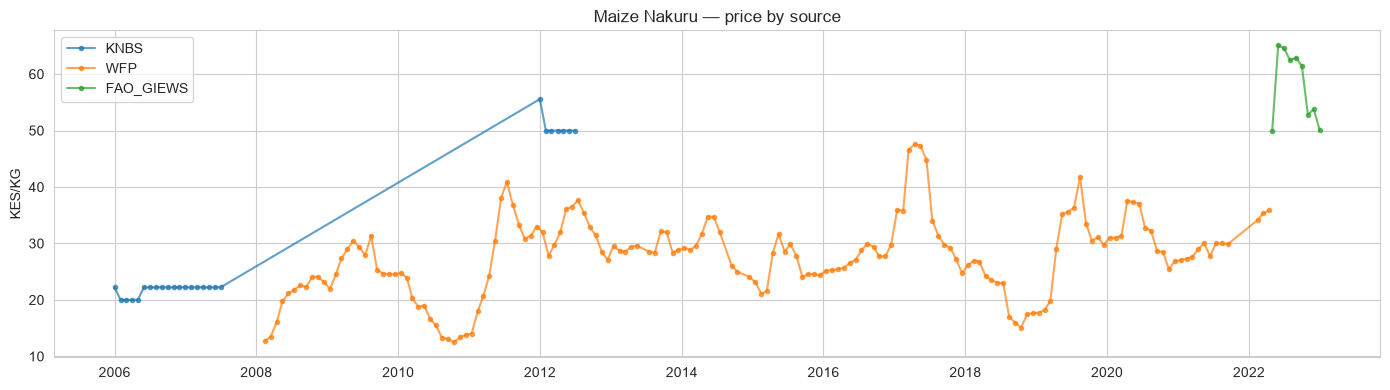

In [59]:
# Diagnose Nakuru Maize — got WORSE after adding data (10.3% → 42.2%)
nakuru = df_v3[(df_v3['commodity']=='Maize') & (df_v3['market']=='Nakuru')]

print('Nakuru Maize by source and pricetype:')
print(nakuru.groupby(['source','pricetype'])['price_per_kg'].agg(['count','min','median','max']).round(2))

print('\nDate ranges by source:')
print(nakuru.groupby('source')['date'].agg(['min','max']))

# Plot to see the break
plt.figure(figsize=(14,4))
for src in nakuru['source'].unique():
    sub = nakuru[nakuru['source']==src].sort_values('date')
    plt.plot(sub['date'], sub['price_per_kg'], marker='.', linestyle='-', label=src, alpha=0.7)
plt.title('Maize Nakuru — price by source')
plt.ylabel('KES/KG')
plt.legend()
plt.tight_layout()
plt.show()

# fix filter by price type before modelkling 


Nakuru Maize Wholesale only:
Records: 173
           count    min  median    max
source                                
FAO_GIEWS      9  49.96   61.43  65.10
WFP          164  12.47   28.45  47.58


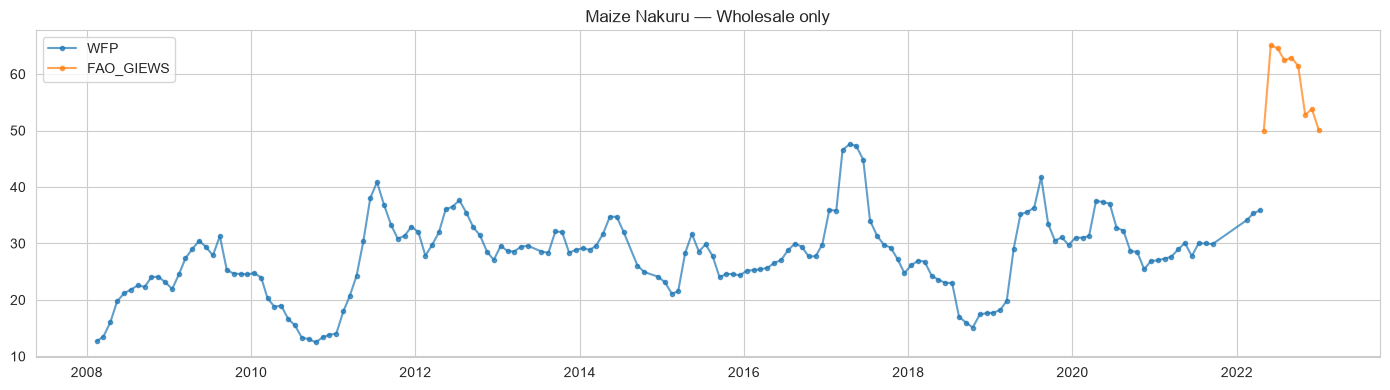

In [60]:
# Only use matching pricetype per series — don't mix retail and wholesale
# Also flag sources with suspicious linear interpolation

def get_clean_series(df, commodity, market, pricetype='Wholesale'):
    """Get a clean single-pricetype series"""
    s = df[
        (df['commodity'] == commodity) &
        (df['market'] == market) &
        (df['pricetype'] == pricetype)
    ].sort_values('date').reset_index(drop=True)
    return s

# Check Nakuru wholesale only
nakuru_ws = get_clean_series(df_v3, 'Maize', 'Nakuru', 'Wholesale')
print('Nakuru Maize Wholesale only:')
print('Records:', len(nakuru_ws))
print(nakuru_ws.groupby('source')['price_per_kg'].agg(['count','min','median','max']).round(2))

plt.figure(figsize=(14,4))
for src in nakuru_ws['source'].unique():
    sub = nakuru_ws[nakuru_ws['source']==src].sort_values('date')
    plt.plot(sub['date'], sub['price_per_kg'], marker='.', linestyle='-', label=src, alpha=0.7)
plt.title('Maize Nakuru — Wholesale only')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
# Drop source fragments < 12 records within a series
counts = df_v3.groupby(['commodity','market','pricetype','source']).size().reset_index(name='n')
keep = counts[counts['n'] >= 12][['commodity','market','pricetype','source']]
df_v3_clean = df_v3.merge(keep, on=['commodity','market','pricetype','source'], how='inner')

print('Before:', len(df_v3), '| After:', len(df_v3_clean))
print('Nakuru Maize wholesale:', 
      len(df_v3_clean[(df_v3_clean['commodity']=='Maize') & 
                      (df_v3_clean['market']=='Nakuru') & 
                      (df_v3_clean['pricetype']=='Wholesale')]))

Before: 31245 | After: 22406
Nakuru Maize wholesale: 164


In [63]:
# ── OPTION A: Drop small source fragments ────────────────────────
counts = df_v3.groupby(['commodity','market','pricetype','source']).size().reset_index(name='n')
keep = counts[counts['n'] >= 12][['commodity','market','pricetype','source']]
df_clean = df_v3.merge(keep, on=['commodity','market','pricetype','source'], how='inner')

print('Before:', len(df_v3), '| After:', len(df_clean))
print('Dropped fragments:', len(counts[counts['n'] < 12]))

Before: 31245 | After: 22406
Dropped fragments: 2384


In [64]:
# ── PROPHET PIPELINE V3 (single pricetype per series) ────────────
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

commodity_params = {
    'Maize': 0.10, 'Maize (white)': 0.10,
    'Beans (dry)': 0.15, 'Beans': 0.15,
    'Sugar': 0.10, 'Wheat flour': 0.10,
    'Potatoes (Irish)': 0.30, 'Rice': 0.10
}

commodities = list(commodity_params.keys())
markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Eldoret','Kitui','Meru','Makueni','Garissa town']
horizons = [3, 6, 12]
MIN_RECORDS = 60
MAPE_THRESHOLD = 25   # models above this are flagged unreliable

all_forecasts, all_metrics, models_trained = [], [], {}

print('Pipeline v3 starting...')
print('-'*72)

for commodity in commodities:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_clean[
                (df_clean['commodity'] == commodity) &
                (df_clean['market'] == market) &
                (df_clean['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = pd.DataFrame({
                'ds': pd.to_datetime(series['date']),
                'y': series['price_per_kg'].values
            }).dropna().drop_duplicates(subset='ds').sort_values('ds')

            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params.get(commodity, 0.1)
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)

            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mae = mean_absolute_error(actual, pred)
            mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

            all_metrics.append({
                'commodity': commodity, 'market': market, 'pricetype': pricetype,
                'n_records': len(pdf), 'mae': round(mae,3), 'mape': round(mape,2),
                'reliable': mape <= MAPE_THRESHOLD
            })

            # Refit on full series for production forecasts
            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)

            for h in horizons:
                fut = m_full.make_future_dataframe(periods=h, freq='MS')
                fc = m_full.predict(fut).tail(h)
                for _, r in fc.iterrows():
                    all_forecasts.append({
                        'commodity': commodity, 'market': market, 'pricetype': pricetype,
                        'forecast_date': r['ds'], 'horizon_months': h,
                        'forecast_price_kes': round(r['yhat'],2),
                        'forecast_lower': round(r['yhat_lower'],2),
                        'forecast_upper': round(r['yhat_upper'],2),
                        'model_mape': round(mape,2),
                        'reliable': mape <= MAPE_THRESHOLD
                    })

            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full
            flag = '✓' if mape <= MAPE_THRESHOLD else '⚠'
            print(f'{flag} {commodity:17s}| {market:13s}| {pricetype:9s}| n={len(pdf):4d} | MAPE {mape:5.1f}%')

print('-'*72)
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)
print(f'Total models: {len(metrics_df)} | Reliable: {metrics_df["reliable"].sum()}')
print(f'Median MAPE (all): {metrics_df["mape"].median():.2f}%')
print(f'Median MAPE (reliable): {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

Pipeline v3 starting...
------------------------------------------------------------------------
✓ Maize            | Nairobi      | Wholesale| n= 189 | MAPE  11.6%
✓ Maize            | Nakuru       | Wholesale| n= 164 | MAPE  10.3%
✓ Maize            | Mombasa      | Wholesale| n= 154 | MAPE  14.2%
✓ Maize            | Kisumu       | Wholesale| n= 165 | MAPE  16.7%
⚠ Maize            | Eldoret      | Wholesale| n= 195 | MAPE  34.0%
✓ Maize (white)    | Nairobi      | Wholesale| n= 165 | MAPE  16.4%
⚠ Maize (white)    | Nakuru       | Wholesale| n=  62 | MAPE  71.8%
✓ Maize (white)    | Mombasa      | Wholesale| n= 167 | MAPE  15.7%
✓ Maize (white)    | Kisumu       | Wholesale| n= 164 | MAPE  24.0%
✓ Maize (white)    | Kitui        | Retail   | n= 239 | MAPE   7.5%
✓ Maize (white)    | Meru         | Retail   | n= 188 | MAPE  12.8%
✓ Maize (white)    | Makueni      | Retail   | n= 188 | MAPE   4.1%
✓ Beans (dry)      | Nairobi      | Wholesale| n= 170 | MAPE  20.1%
✓ Beans (dry)      

In [65]:
# ── MODEL QUALITY SUMMARY ────────────────────────────────────────
print('=== BY COMMODITY ===')
print(metrics_df.groupby('commodity').agg(
    models=('mape','count'),
    reliable=('reliable','sum'),
    median_mape=('mape','median')
).round(2).to_string())

print('\n=== RELIABLE MODELS (deployable) ===')
print(metrics_df[metrics_df['reliable']]
      .sort_values('mape')[['commodity','market','pricetype','n_records','mae','mape']]
      .to_string(index=False))

print('\n=== UNRELIABLE MODELS (excluded from deployment) ===')
print(metrics_df[~metrics_df['reliable']]
      .sort_values('mape', ascending=False)[['commodity','market','pricetype','n_records','mape']]
      .to_string(index=False))

=== BY COMMODITY ===
                  models  reliable  median_mape
commodity                                      
Beans                  5         4        18.83
Beans (dry)            6         5        17.63
Maize                  5         4        14.16
Maize (white)          7         6        15.73
Potatoes (Irish)       4         1        38.47

=== RELIABLE MODELS (deployable) ===
       commodity  market pricetype  n_records    mae  mape
   Maize (white) Makueni    Retail        188  2.281  4.06
   Maize (white)   Kitui    Retail        239  4.286  7.46
           Beans  Kisumu Wholesale        160  6.498  9.26
     Beans (dry)   Kitui    Retail        164  8.903  9.58
           Maize  Nakuru Wholesale        164  3.188 10.26
           Maize Nairobi Wholesale        189  3.716 11.62
   Maize (white)    Meru    Retail        188  7.342 12.85
           Beans  Nakuru Wholesale        129  8.330 13.48
     Beans (dry)  Kisumu Wholesale        134 11.872 13.92
           Maiz

# lets drop potatoes 


In [67]:
# ── PIPELINE V4 — Potatoes dropped ───────────────────────────────
commodity_params = {
    'Maize': 0.10,
    'Maize (white)': 0.10,
    'Beans (dry)': 0.15,
    'Beans': 0.15,
    'Sugar': 0.10,
    'Wheat flour': 0.10,
    'Rice': 0.10
}

commodities = list(commodity_params.keys())
markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Eldoret','Kitui','Meru','Makueni','Garissa town']
horizons = [3, 6, 12]
MIN_RECORDS = 60
MAPE_THRESHOLD = 25

all_forecasts, all_metrics, models_trained = [], [], {}

print('Pipeline v4 starting (Potatoes excluded)...')
print('-'*72)

for commodity in commodities:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_clean[
                (df_clean['commodity'] == commodity) &
                (df_clean['market'] == market) &
                (df_clean['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = pd.DataFrame({
                'ds': pd.to_datetime(series['date']),
                'y': series['price_per_kg'].values
            }).dropna().drop_duplicates(subset='ds').sort_values('ds')

            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)

            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mae = mean_absolute_error(actual, pred)
            mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

            all_metrics.append({
                'commodity': commodity, 'market': market, 'pricetype': pricetype,
                'n_records': len(pdf), 'mae': round(mae,3), 'mape': round(mape,2),
                'reliable': mape <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)

            for h in horizons:
                fut = m_full.make_future_dataframe(periods=h, freq='MS')
                fc = m_full.predict(fut).tail(h)
                for _, r in fc.iterrows():
                    all_forecasts.append({
                        'commodity': commodity, 'market': market, 'pricetype': pricetype,
                        'forecast_date': r['ds'], 'horizon_months': h,
                        'forecast_price_kes': round(r['yhat'],2),
                        'forecast_lower': round(r['yhat_lower'],2),
                        'forecast_upper': round(r['yhat_upper'],2),
                        'model_mape': round(mape,2),
                        'reliable': mape <= MAPE_THRESHOLD
                    })

            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full
            flag = '✓' if mape <= MAPE_THRESHOLD else '⚠'
            print(f'{flag} {commodity:15s}| {market:13s}| {pricetype:9s}| n={len(pdf):4d} | MAPE {mape:5.1f}%')

print('-'*72)
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)

print(f'Total models    : {len(metrics_df)}')
print(f'Reliable models : {metrics_df["reliable"].sum()}')
print(f'Median MAPE     : {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')
print(f'Best model      : {metrics_df.loc[metrics_df["mape"].idxmin(), "commodity"]} '
      f'{metrics_df.loc[metrics_df["mape"].idxmin(), "market"]} '
      f'({metrics_df["mape"].min():.2f}%)')

Pipeline v4 starting (Potatoes excluded)...
------------------------------------------------------------------------
✓ Maize          | Nairobi      | Wholesale| n= 189 | MAPE  11.6%
✓ Maize          | Nakuru       | Wholesale| n= 164 | MAPE  10.3%
✓ Maize          | Mombasa      | Wholesale| n= 154 | MAPE  14.2%
✓ Maize          | Kisumu       | Wholesale| n= 165 | MAPE  16.7%
⚠ Maize          | Eldoret      | Wholesale| n= 195 | MAPE  34.0%
✓ Maize (white)  | Nairobi      | Wholesale| n= 165 | MAPE  16.4%
⚠ Maize (white)  | Nakuru       | Wholesale| n=  62 | MAPE  71.8%
✓ Maize (white)  | Mombasa      | Wholesale| n= 167 | MAPE  15.7%
✓ Maize (white)  | Kisumu       | Wholesale| n= 164 | MAPE  24.0%
✓ Maize (white)  | Kitui        | Retail   | n= 239 | MAPE   7.5%
✓ Maize (white)  | Meru         | Retail   | n= 188 | MAPE  12.8%
✓ Maize (white)  | Makueni      | Retail   | n= 188 | MAPE   4.1%
✓ Beans (dry)    | Nairobi      | Wholesale| n= 170 | MAPE  20.1%
✓ Beans (dry)    | Nakuru

In [69]:
# ── PRICE ANOMALY DETECTION (v2) ─────────────────────────────────
from datetime import timedelta

RECENCY_CUTOFF = df_clean['date'].max() - pd.DateOffset(months=6)
anomalies = []

for (commodity, market, pricetype), g in df_clean.groupby(['commodity','market','pricetype']):
    # Guard 1 — only commodities we actually model
    if commodity not in commodity_params:
        continue

    g = g.sort_values('date')
    if len(g) < 24:
        continue

    latest = g.iloc[-1]

    # Guard 2 — only recent observations count as live alerts
    if latest['date'] < RECENCY_CUTOFF:
        continue

    hist = g.iloc[:-1]['price_per_kg']
    q1, q3 = hist.quantile(0.25), hist.quantile(0.75)
    iqr = q3 - q1

    # Guard 3 — skip degenerate distributions (flat/interpolated series)
    if iqr <= 0 or hist.std() == 0:
        continue

    lower = max(q1 - 1.5*iqr, 0)   # price floor can't be negative
    upper = q3 + 1.5*iqr
    price = latest['price_per_kg']

    if price > upper:
        status, dev = 'SPIKE', round((price - upper)/upper*100, 1)
    elif price < lower:
        status, dev = 'CRASH', round((lower - price)/lower*100, 1)
    else:
        status, dev = 'NORMAL', 0.0

    anomalies.append({
        'commodity': commodity, 'market': market, 'pricetype': pricetype,
        'latest_date': latest['date'].date(), 'latest_price': round(price,2),
        'normal_low': round(lower,2), 'normal_high': round(upper,2),
        'status': status, 'deviation_pct': dev
    })

anomalies_df = pd.DataFrame(anomalies)

print(f'Series monitored : {len(anomalies_df)}')
print(f'Recency cutoff   : {RECENCY_CUTOFF.date()}')
print()
print(anomalies_df['status'].value_counts().to_string())

alerts = anomalies_df[anomalies_df['status'] != 'NORMAL'].sort_values('deviation_pct', ascending=False)
print('\n=== ACTIVE ALERTS ===')
print(alerts.to_string(index=False) if len(alerts) else 'No active price anomalies detected')

Series monitored : 76
Recency cutoff   : 2026-02-15

status
NORMAL    74
SPIKE      2

=== ACTIVE ALERTS ===
    commodity       market pricetype latest_date  latest_price  normal_low  normal_high status  deviation_pct
Maize (white) Taita Taveta    Retail  2026-05-01          57.0       27.35        55.75  SPIKE            2.2
Maize (white)     Marsabit    Retail  2026-05-01          70.0       26.87        68.68  SPIKE            1.9


In [70]:
# PRICE ANOMALY DETECTION 
# Flags markets where the latest observed price breaches historical IQR bounds
anomalies = []

for (commodity, market, pricetype), g in df_clean.groupby(['commodity','market','pricetype']):
    g = g.sort_values('date')
    if len(g) < 24:
        continue

    hist = g.iloc[:-1]['price_per_kg']
    latest = g.iloc[-1]

    q1, q3 = hist.quantile(0.25), hist.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

    price = latest['price_per_kg']
    if price > upper:
        status, dev = 'SPIKE', round((price - upper)/upper*100, 1)
    elif price < lower:
        status, dev = 'CRASH', round((lower - price)/lower*100, 1)
    else:
        status, dev = 'NORMAL', 0.0

    anomalies.append({
        'commodity': commodity, 'market': market, 'pricetype': pricetype,
        'latest_date': latest['date'], 'latest_price': round(price,2),
        'normal_range_low': round(lower,2), 'normal_range_high': round(upper,2),
        'status': status, 'deviation_pct': dev
    })

anomalies_df = pd.DataFrame(anomalies)

print('=== ANOMALY DETECTION ===')
print(anomalies_df['status'].value_counts().to_string())
print('\nActive alerts:')
alerts = anomalies_df[anomalies_df['status'] != 'NORMAL'].sort_values('deviation_pct', ascending=False)
print(alerts.to_string(index=False) if len(alerts) else 'None')

=== ANOMALY DETECTION ===
status
NORMAL    274
SPIKE      25
CRASH       1

Active alerts:
          commodity                 market pricetype latest_date  latest_price  normal_range_low  normal_range_high status  deviation_pct
              Maize                 Nakuru    Retail  2012-07-01         50.00             22.22              22.22  SPIKE          125.0
               Kale        Kibuye (Kisumu) Wholesale  2026-07-15         95.19             13.48              51.72  SPIKE           84.0
      Beans (mixed)                  Kwale    Retail  2023-01-01        182.00             50.00             130.00  SPIKE           40.0
     Beans (yellow) Marigat town (Baringo) Wholesale  2023-07-15        157.50            119.62             120.62  SPIKE           30.6
   Beans (rosecoco) Marigat town (Baringo) Wholesale  2023-06-15        135.00             80.31             106.15  SPIKE           27.2
               Salt           IFO (Daadab)    Retail  2026-08-15         87.10   

In [71]:
# Optional — tiered severity instead of binary flag
def classify(price, q1, q3, iqr):
    upper_watch = q3 + 1.0*iqr
    upper_alert = q3 + 1.5*iqr
    upper_severe = q3 + 2.5*iqr
    if price > upper_severe:  return 'SEVERE'
    if price > upper_alert:   return 'ALERT'
    if price > upper_watch:   return 'WATCH'
    return 'NORMAL'

In [72]:
import joblib, os

os.makedirs('../../data/exports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

forecasts_df.to_csv('../../data/exports/all_forecasts.csv', index=False)
metrics_df.to_csv('../../data/exports/model_metrics.csv', index=False)
anomalies_df.to_csv('../../data/exports/price_anomalies.csv', index=False)

saved = 0
for key, model in models_trained.items():
    commodity, market, pricetype = key.split('|')
    row = metrics_df[(metrics_df['commodity']==commodity) &
                     (metrics_df['market']==market) &
                     (metrics_df['pricetype']==pricetype)]
    if len(row) and row.iloc[0]['reliable']:
        fname = key.replace('|','_').replace(' ','_').replace('(','').replace(')','')
        joblib.dump(model, f'../../models/prophet_{fname}.joblib')
        saved += 1

print(f'Forecasts : {len(forecasts_df)} rows')
print(f'Metrics   : {len(metrics_df)} rows')
print(f'Anomalies : {len(anomalies_df)} rows')
print(f'Models    : {saved} reliable models saved')

Forecasts : 483 rows
Metrics   : 23 rows
Anomalies : 300 rows
Models    : 19 reliable models saved


In [75]:
# Are Maize and Maize (white) the same commodity under different labels?
for market in ['Nairobi', 'Nakuru', 'Mombasa', 'Kisumu']:
    print(f'\n=== {market} ===')
    for comm in ['Maize', 'Maize (white)']:
        s = df_clean[(df_clean['commodity']==comm) & 
                     (df_clean['market']==market) &
                     (df_clean['pricetype']=='Wholesale')]
        if len(s):
            print(f'{comm:15s} | n={len(s):4d} | {s["date"].min().date()} to {s["date"].max().date()} '
                  f'| median {s["price_per_kg"].median():.2f} | sources: {s["source"].unique().tolist()}')


=== Nairobi ===
Maize           | n= 189 | 2006-01-15 to 2022-03-15 | median 31.05 | sources: ['WFP']
Maize (white)   | n= 165 | 2006-01-15 to 2020-03-15 | median 30.00 | sources: ['WFP']

=== Nakuru ===
Maize           | n= 164 | 2008-02-15 to 2022-04-15 | median 28.45 | sources: ['WFP']
Maize (white)   | n=  62 | 2015-01-15 to 2020-03-15 | median 27.89 | sources: ['WFP']

=== Mombasa ===
Maize           | n= 154 | 2006-01-15 to 2021-11-15 | median 28.31 | sources: ['WFP']
Maize (white)   | n= 167 | 2006-01-15 to 2020-03-15 | median 28.89 | sources: ['WFP']

=== Kisumu ===
Maize           | n= 165 | 2006-01-15 to 2022-02-15 | median 31.03 | sources: ['WFP', 'FAO_GIEWS']
Maize (white)   | n= 164 | 2006-01-15 to 2019-10-15 | median 34.25 | sources: ['WFP']


In [76]:
# If both labels exist for the same market-month, they're duplicates not variants
for market in ['Nairobi','Nakuru','Mombasa','Kisumu']:
    a = df_clean[(df_clean['commodity']=='Maize') & (df_clean['market']==market) &
                 (df_clean['pricetype']=='Wholesale')][['date','price_per_kg']]
    b = df_clean[(df_clean['commodity']=='Maize (white)') & (df_clean['market']==market) &
                 (df_clean['pricetype']=='Wholesale')][['date','price_per_kg']]
    merged = a.merge(b, on='date', suffixes=('_maize','_white'))
    if len(merged):
        diff = (merged['price_per_kg_maize'] - merged['price_per_kg_white'])
        print(f'{market:10s} | overlapping months: {len(merged):3d} | '
              f'mean diff: {diff.mean():6.2f} | corr: {merged["price_per_kg_maize"].corr(merged["price_per_kg_white"]):.3f}')

Nairobi    | overlapping months: 164 | mean diff:  -0.46 | corr: 0.953
Nakuru     | overlapping months:  62 | mean diff:  -0.16 | corr: 0.941
Mombasa    | overlapping months: 142 | mean diff:   0.24 | corr: 0.979
Kisumu     | overlapping months: 140 | mean diff:  -1.98 | corr: 0.951


In [77]:
for market in ['Nairobi','Nakuru','Mombasa','Kisumu','Eldoret']:
    a = df_clean[(df_clean['commodity']=='Beans') & (df_clean['market']==market) &
                 (df_clean['pricetype']=='Wholesale')][['date','price_per_kg']]
    b = df_clean[(df_clean['commodity']=='Beans (dry)') & (df_clean['market']==market) &
                 (df_clean['pricetype']=='Wholesale')][['date','price_per_kg']]
    merged = a.merge(b, on='date', suffixes=('_beans','_dry'))
    if len(merged) > 10:
        diff = merged['price_per_kg_beans'] - merged['price_per_kg_dry']
        print(f'{market:10s} | overlap: {len(merged):3d} | mean diff: {diff.mean():7.2f} | '
              f'corr: {merged["price_per_kg_beans"].corr(merged["price_per_kg_dry"]):.3f}')

Nairobi    | overlap: 135 | mean diff:   -3.36 | corr: 0.844
Nakuru     | overlap:  48 | mean diff:   -9.89 | corr: 0.431
Mombasa    | overlap: 142 | mean diff:    0.10 | corr: 0.876
Kisumu     | overlap: 130 | mean diff:   -5.73 | corr: 0.835


### cross validation and ensemble 


In [78]:
# ── PROPHET CROSS-VALIDATION ─────────────────────────────────────
from prophet.diagnostics import cross_validation, performance_metrics

cv_results = []

for key, model in models_trained.items():
    commodity, market, pricetype = key.split('|')

    # Only cross-validate models already flagged reliable
    row = metrics_df[(metrics_df['commodity']==commodity) &
                     (metrics_df['market']==market) &
                     (metrics_df['pricetype']==pricetype)]
    if not len(row) or not row.iloc[0]['reliable']:
        continue

    n = row.iloc[0]['n_records']
    if n < 100:          # need enough history to cut multiple folds
        continue

    try:
        # initial = training window, period = gap between folds, horizon = forecast length
        df_cv = cross_validation(
            model,
            initial=f'{int(n*0.6)*30} days',
            period='180 days',
            horizon='365 days',
            disable_tqdm=True
        )
        perf = performance_metrics(df_cv, rolling_window=1)

        cv_results.append({
            'commodity': commodity,
            'market': market,
            'pricetype': pricetype,
            'holdout_mape': row.iloc[0]['mape'],
            'cv_mape': round(perf['mape'].values[0]*100, 2),
            'cv_mae': round(perf['mae'].values[0], 3),
            'cv_rmse': round(perf['rmse'].values[0], 3),
            'n_folds': df_cv['cutoff'].nunique()
        })
        print(f"✓ {commodity:15s}| {market:12s}| holdout {row.iloc[0]['mape']:5.1f}% → CV {perf['mape'].values[0]*100:5.1f}%")

    except Exception as e:
        print(f"✗ {commodity:15s}| {market:12s}| skipped ({str(e)[:40]})")

cv_df = pd.DataFrame(cv_results)
print('\n' + '-'*60)
print(f'Models cross-validated: {len(cv_df)}')
print(f'Median holdout MAPE: {cv_df["holdout_mape"].median():.2f}%')
print(f'Median CV MAPE:      {cv_df["cv_mape"].median():.2f}%')

✓ Maize          | Nairobi     | holdout  11.6% → CV  18.6%
✓ Maize          | Nakuru      | holdout  10.3% → CV  24.7%
✓ Maize          | Mombasa     | holdout  14.2% → CV  25.4%
✓ Maize          | Kisumu      | holdout  16.7% → CV  20.0%
✓ Maize (white)  | Nairobi     | holdout  16.4% → CV  22.5%
✓ Maize (white)  | Mombasa     | holdout  15.7% → CV  22.9%
✓ Maize (white)  | Kisumu      | holdout  24.0% → CV  22.0%
✓ Maize (white)  | Kitui       | holdout   7.5% → CV  23.0%
✓ Maize (white)  | Meru        | holdout  12.8% → CV  26.1%
✓ Maize (white)  | Makueni     | holdout   4.1% → CV  21.7%
✓ Beans (dry)    | Nairobi     | holdout  20.1% → CV  11.0%
✓ Beans (dry)    | Nakuru      | holdout  15.2% → CV  18.7%
✓ Beans (dry)    | Kisumu      | holdout  13.9% → CV   9.6%
✓ Beans (dry)    | Kitui       | holdout   9.6% → CV   9.0%
✓ Beans          | Nairobi     | holdout  18.8% → CV  16.4%
✓ Beans          | Nakuru      | holdout  13.5% → CV  15.9%
✓ Beans          | Kisumu      | holdout

In [80]:
df_merged = df_clean.copy()
df_merged['commodity'] = df_merged['commodity'].replace({'Maize (white)': 'Maize'})

df_merged = (df_merged
    .assign(month_key=df_merged['date'].dt.to_period('M'))
    .groupby(['commodity','market','pricetype','month_key'], as_index=False)
    .agg({
        'date': 'first',
        'price_per_kg': 'mean',
        'rainfall_mm': 'first',
        'GPR': 'first',
        'diesel_price_kes': 'first',
        'source': 'first',
        'admin1': 'first',
        'latitude': 'first',
        'longitude': 'first',
        'category': 'first'
    })
    .drop(columns='month_key'))

print('Before:', len(df_clean), '| After:', len(df_merged))

Before: 22406 | After: 21712


In [83]:
commodity_params = {
    'Maize': 0.10,
    'Beans (dry)': 0.15,
    'Beans': 0.15,
    'Sorghum': 0.15,
}

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Eldoret town (Uasin Gishu)','Garissa town']

In [86]:
commodity_params = {
    'Maize': 0.10,
    'Beans': 0.15,
    'Beans (dry)': 0.15,
    'Beans (mixed)': 0.15,
    'Sorghum': 0.15,
    'Maize meal': 0.10,
}

In [87]:
all_forecasts, all_metrics, models_trained = [], [], {}
horizons = [3, 6, 12]
MIN_RECORDS = 60
MAPE_THRESHOLD = 25

print('Pipeline v5 — Maize consolidated, Sorghum added')
print('-'*72)

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_merged[
                (df_merged['commodity'] == commodity) &
                (df_merged['market'] == market) &
                (df_merged['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = pd.DataFrame({
                'ds': pd.to_datetime(series['date']),
                'y': series['price_per_kg'].values
            }).dropna().drop_duplicates(subset='ds').sort_values('ds')

            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)

            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mae = mean_absolute_error(actual, pred)
            mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

            all_metrics.append({
                'commodity': commodity, 'market': market, 'pricetype': pricetype,
                'n_records': len(pdf), 'mae': round(mae,3), 'mape': round(mape,2),
                'reliable': mape <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)

            for h in horizons:
                fut = m_full.make_future_dataframe(periods=h, freq='MS')
                fc = m_full.predict(fut).tail(h)
                for _, r in fc.iterrows():
                    all_forecasts.append({
                        'commodity': commodity, 'market': market, 'pricetype': pricetype,
                        'forecast_date': r['ds'], 'horizon_months': h,
                        'forecast_price_kes': round(r['yhat'],2),
                        'forecast_lower': round(r['yhat_lower'],2),
                        'forecast_upper': round(r['yhat_upper'],2),
                        'model_mape': round(mape,2),
                        'reliable': mape <= MAPE_THRESHOLD
                    })

            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full
            flag = '✓' if mape <= MAPE_THRESHOLD else '⚠'
            print(f'{flag} {commodity:13s}| {market:28s}| {pricetype:9s}| n={len(pdf):4d} | MAPE {mape:5.1f}%')

print('-'*72)
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)
print(f'Models: {len(metrics_df)} | Reliable: {metrics_df["reliable"].sum()} | '
      f'Median MAPE: {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

Pipeline v5 — Maize consolidated, Sorghum added
------------------------------------------------------------------------
✓ Maize        | Nairobi                     | Wholesale| n= 190 | MAPE  12.1%
✓ Maize        | Nakuru                      | Wholesale| n= 164 | MAPE   9.9%
✓ Maize        | Mombasa                     | Wholesale| n= 179 | MAPE  15.6%
✓ Maize        | Kisumu                      | Wholesale| n= 168 | MAPE  16.5%
✓ Maize        | Kitui                       | Retail   | n= 239 | MAPE   7.5%
✓ Maize        | Meru                        | Retail   | n= 188 | MAPE  12.8%
✓ Maize        | Makueni                     | Retail   | n= 188 | MAPE   4.1%
⚠ Maize        | Eldoret                     | Wholesale| n= 195 | MAPE  34.0%
✓ Maize        | Eldoret town (Uasin Gishu)  | Wholesale| n= 193 | MAPE  14.1%
✓ Beans        | Nairobi                     | Wholesale| n= 144 | MAPE  18.8%
✓ Beans        | Nakuru                      | Wholesale| n= 129 | MAPE  13.5%
⚠ Beans   

In [91]:
# Eldoret is one market under two labels; dates differ only by day-of-month
df_merged['market'] = df_merged['market'].replace({
    'Eldoret town (Uasin Gishu)': 'Eldoret'
})

df_merged = (df_merged
    .assign(month_key=df_merged['date'].dt.to_period('M'))
    .groupby(['commodity','market','pricetype','month_key'], as_index=False)
    .agg({
        'date': 'first',
        'price_per_kg': 'mean',
        'rainfall_mm': 'first',
        'GPR': 'first',
        'diesel_price_kes': 'first',
        'source': 'first',
        'admin1': 'first',
        'latitude': 'first',
        'longitude': 'first',
        'category': 'first'
    })
    .drop(columns='month_key'))

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Garissa town']

print('After Eldoret consolidation:', len(df_merged))
for comm in ['Maize','Beans','Beans (dry)','Sorghum']:
    n = len(df_merged[(df_merged['commodity']==comm) & (df_merged['market']=='Eldoret')])
    print(f'  {comm:13s} Eldoret n={n}')

After Eldoret consolidation: 21368
  Maize         Eldoret n=226
  Beans         Eldoret n=156
  Beans (dry)   Eldoret n=184
  Sorghum       Eldoret n=105


In [92]:
all_forecasts, all_metrics, models_trained = [], [], {}
horizons = [3, 6, 12]
MIN_RECORDS = 60
MAPE_THRESHOLD = 25

print('Pipeline v6 — Eldoret consolidated')
print('-'*72)

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_merged[
                (df_merged['commodity'] == commodity) &
                (df_merged['market'] == market) &
                (df_merged['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = pd.DataFrame({
                'ds': pd.to_datetime(series['date']),
                'y': series['price_per_kg'].values
            }).dropna().drop_duplicates(subset='ds').sort_values('ds')

            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)

            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mae = mean_absolute_error(actual, pred)
            mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

            all_metrics.append({
                'commodity': commodity, 'market': market, 'pricetype': pricetype,
                'n_records': len(pdf), 'mae': round(mae,3), 'mape': round(mape,2),
                'reliable': mape <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)

            for h in horizons:
                fut = m_full.make_future_dataframe(periods=h, freq='MS')
                fc = m_full.predict(fut).tail(h)
                for _, r in fc.iterrows():
                    all_forecasts.append({
                        'commodity': commodity, 'market': market, 'pricetype': pricetype,
                        'forecast_date': r['ds'], 'horizon_months': h,
                        'forecast_price_kes': round(r['yhat'],2),
                        'forecast_lower': round(r['yhat_lower'],2),
                        'forecast_upper': round(r['yhat_upper'],2),
                        'model_mape': round(mape,2),
                        'reliable': mape <= MAPE_THRESHOLD
                    })

            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full
            flag = '✓' if mape <= MAPE_THRESHOLD else '⚠'
            print(f'{flag} {commodity:14s}| {market:13s}| {pricetype:9s}| n={len(pdf):4d} | MAPE {mape:5.1f}%')

print('-'*72)
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)
print(f'Models: {len(metrics_df)} | Reliable: {metrics_df["reliable"].sum()} | '
      f'Median MAPE: {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

Pipeline v6 — Eldoret consolidated
------------------------------------------------------------------------
✓ Maize         | Nairobi      | Wholesale| n= 190 | MAPE  12.1%
✓ Maize         | Nakuru       | Wholesale| n= 164 | MAPE   9.9%
✓ Maize         | Mombasa      | Wholesale| n= 179 | MAPE  15.6%
✓ Maize         | Kisumu       | Wholesale| n= 168 | MAPE  16.5%
✓ Maize         | Kitui        | Retail   | n= 239 | MAPE   7.5%
✓ Maize         | Meru         | Retail   | n= 188 | MAPE  12.8%
✓ Maize         | Makueni      | Retail   | n= 188 | MAPE   4.1%
⚠ Maize         | Eldoret      | Wholesale| n= 200 | MAPE  33.8%
✓ Beans         | Nairobi      | Wholesale| n= 144 | MAPE  18.8%
✓ Beans         | Nakuru       | Wholesale| n= 129 | MAPE  13.5%
⚠ Beans         | Mombasa      | Wholesale| n= 143 | MAPE  37.2%
✓ Beans         | Kisumu       | Wholesale| n= 160 | MAPE   9.3%
✓ Beans         | Eldoret      | Wholesale| n= 156 | MAPE  24.2%
✓ Beans (dry)   | Nairobi      | Wholesale| n= 

In [93]:
# ── MAPE BY FORECAST HORIZON ─────────────────────────────────────
horizon_results = []

for key in models_trained:
    commodity, market, pricetype = key.split('|')

    row = metrics_df[(metrics_df['commodity']==commodity) &
                     (metrics_df['market']==market) &
                     (metrics_df['pricetype']==pricetype)]
    if not len(row) or not row.iloc[0]['reliable']:
        continue

    series = df_merged[(df_merged['commodity']==commodity) &
                       (df_merged['market']==market) &
                       (df_merged['pricetype']==pricetype)].sort_values('date')

    pdf = pd.DataFrame({
        'ds': pd.to_datetime(series['date']),
        'y': series['price_per_kg'].values
    }).dropna().drop_duplicates(subset='ds').sort_values('ds')

    for h in [3, 6, 12]:
        train_h, test_h = pdf.iloc[:-h], pdf.iloc[-h:]

        m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                    weekly_seasonality=False, daily_seasonality=False,
                    changepoint_prior_scale=commodity_params[commodity])
        m.fit(train_h)

        pred = m.predict(test_h[['ds']])['yhat'].values
        actual = test_h['y'].values

        horizon_results.append({
            'commodity': commodity,
            'market': market,
            'pricetype': pricetype,
            'horizon': h,
            'mae': round(mean_absolute_error(actual, pred), 3),
            'mape': round(np.mean(np.abs((actual - pred)/(actual + 1e-8)))*100, 2)
        })

horizon_df = pd.DataFrame(horizon_results)

print('=== ACCURACY BY HORIZON ===')
print(horizon_df.groupby('horizon')['mape']
      .agg(models='count', median='median', mean='mean').round(2).to_string())

print('\n=== MEDIAN MAPE BY COMMODITY × HORIZON ===')
print(horizon_df.pivot_table(index='commodity', columns='horizon',
                             values='mape', aggfunc='median').round(2).to_string())

# Attach horizon-specific MAPE to the forecast export
forecasts_df = forecasts_df.merge(
    horizon_df[['commodity','market','pricetype','horizon','mape']]
        .rename(columns={'horizon':'horizon_months','mape':'horizon_mape'}),
    on=['commodity','market','pricetype','horizon_months'],
    how='left'
)

print(f'\nForecasts now carry horizon-specific MAPE: {forecasts_df["horizon_mape"].notna().sum()} rows')

=== ACCURACY BY HORIZON ===
         models  median   mean
horizon                       
3            25   13.16  14.72
6            25   14.25  15.25
12           25   15.59  15.43

=== MEDIAN MAPE BY COMMODITY × HORIZON ===
horizon           3      6      12
commodity                         
Beans          13.70  16.52  16.16
Beans (dry)    13.04  16.58  14.54
Beans (mixed)  10.60  11.06  16.29
Maize          17.73  11.75  12.13
Maize meal      9.83   9.06  20.02
Sorghum        13.01  20.10  22.80

Forecasts now carry horizon-specific MAPE: 525 rows


In [94]:
# Every wholesale series, no market exclusions
ws_all = df_merged[df_merged['pricetype']=='Wholesale']

counts = (ws_all.groupby(['commodity','market']).size()
          .reset_index(name='n')
          .sort_values('n', ascending=False))

print(f'Total wholesale series : {len(counts)}')
print(f'≥60 records            : {(counts["n"]>=60).sum()}')
print(f'40–59 records          : {((counts["n"]>=40)&(counts["n"]<60)).sum()}')
print(f'<40 records            : {(counts["n"]<40).sum()}\n')

print('=== ALL WHOLESALE SERIES ≥60 RECORDS ===')
print(counts[counts['n']>=60].to_string(index=False))

print('\n=== BY COMMODITY ===')
print(counts[counts['n']>=60].groupby('commodity')
      .agg(series=('n','count'), best=('n','max'), total_records=('n','sum'))
      .sort_values('series', ascending=False).to_string())

Total wholesale series : 180
≥60 records            : 25
40–59 records          : 12
<40 records            : 143

=== ALL WHOLESALE SERIES ≥60 RECORDS ===
       commodity  market   n
           Maize Eldoret 200
           Maize Nairobi 190
           Maize Mombasa 179
     Beans (dry) Eldoret 170
Potatoes (Irish) Nairobi 170
     Beans (dry) Nairobi 170
         Sorghum Nairobi 169
           Maize  Kisumu 168
     Beans (dry) Mombasa 167
           Maize  Nakuru 164
         Sorghum  Kisumu 161
           Beans  Kisumu 160
           Beans Eldoret 156
         Sorghum   Kitui 145
           Beans Nairobi 144
           Beans Mombasa 143
Potatoes (Irish)   Kitui 142
     Beans (dry)  Kisumu 134
           Beans  Nakuru 129
Potatoes (Irish)  Kisumu 127
Potatoes (Irish) Eldoret 123
         Sorghum Eldoret 105
Potatoes (Irish)  Nakuru  62
         Sorghum  Nakuru  62
     Beans (dry)  Nakuru  62

=== BY COMMODITY ===
                  series  best  total_records
commodity             

In [95]:
rt_all = df_merged[df_merged['pricetype']=='Retail']
counts_r = (rt_all.groupby(['commodity','market']).size()
            .reset_index(name='n').sort_values('n', ascending=False))

print(f'Total retail series : {len(counts_r)}')
print(f'≥60 records         : {(counts_r["n"]>=60).sum()}\n')
print(counts_r[counts_r['n']>=60].to_string(index=False))

Total retail series : 270
≥60 records         : 39

              commodity            market   n
                  Maize          Marsabit 239
                  Maize             Kitui 239
             Maize meal           Nairobi 231
                  Maize           Mandera 221
            Beans (dry)            Nakuru 205
                  Maize           Garissa 191
                  Maize            Kilifi 191
                  Maize             Kwale 191
          Beans (mixed)             Kitui 190
                  Maize            Isiolo 188
                  Maize              Meru 188
                  Maize              Lamu 188
                  Maize           Makueni 188
                  Maize       Embu-Mbeere 188
                  Maize        Tana River 188
                  Maize     Tharaka Nithi 188
                  Maize           Turkana 188
                  Maize      Taita Taveta 188
                  Maize             Wajir 188
        Oil (vegetable)     

In [96]:
for mkt in ['Nyeri','Kiambu','Karatina (Nyeri)','Garissa town','Wajir','Mandera','Marsabit','Isiolo']:
    sub = df_merged[df_merged['market']==mkt]
    if len(sub):
        top = sub.groupby(['commodity','pricetype']).size().sort_values(ascending=False).head(3)
        print(f'{mkt:22s} | total {len(sub):4d}')
        for (c,p), n in top.items():
            print(f'                       {c:18s} {p:9s} n={n}')
    else:
        print(f'{mkt:22s} | not in dataset')
        

Nyeri                  | not in dataset
Kiambu                 | not in dataset
Karatina (Nyeri)       | total  216
                       Cabbage            Wholesale n=32
                       Kale               Wholesale n=31
                       Tomatoes           Wholesale n=30
Garissa town           | not in dataset
Wajir                  | total  188
                       Maize              Retail    n=188
Mandera                | total  221
                       Maize              Retail    n=221
Marsabit               | total  303
                       Maize              Retail    n=239
                       Beans (mixed)      Retail    n=64
Isiolo                 | total  188
                       Maize              Retail    n=188


In [97]:
markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Wajir','Mandera','Marsabit','Isiolo']

region_map = {
    'Nairobi': 'Nairobi',
    'Nakuru': 'Rift Valley',
    'Eldoret': 'Rift Valley',
    'Mombasa': 'Coast',
    'Kisumu': 'Nyanza',
    'Kitui': 'Eastern',
    'Meru': 'Eastern',
    'Makueni': 'Eastern',
    'Wajir': 'North Eastern',
    'Mandera': 'North Eastern',
    'Marsabit': 'North Eastern',
    'Isiolo': 'Eastern'
}

In [98]:
# ── PIPELINE V7 — full regional coverage ─────────────────────────
commodity_params = {
    'Maize': 0.10,
    'Beans': 0.15,
    'Beans (dry)': 0.15,
    'Beans (mixed)': 0.15,
    'Sorghum': 0.15,
    'Maize meal': 0.10,
}

markets = ['Nairobi','Nakuru','Mombasa','Kisumu','Kitui','Meru','Makueni',
           'Eldoret','Wajir','Mandera','Marsabit','Isiolo']

region_map = {
    'Nairobi': 'Nairobi',
    'Nakuru': 'Rift Valley',
    'Eldoret': 'Rift Valley',
    'Mombasa': 'Coast',
    'Kisumu': 'Nyanza',
    'Kitui': 'Eastern',
    'Meru': 'Eastern',
    'Makueni': 'Eastern',
    'Isiolo': 'Eastern',
    'Wajir': 'North Eastern',
    'Mandera': 'North Eastern',
    'Marsabit': 'North Eastern',
}

horizons = [3, 6, 12]
MIN_RECORDS = 60
MAPE_THRESHOLD = 25

all_forecasts, all_metrics, models_trained = [], [], {}

print('Pipeline v7 — arid counties added')
print('-'*78)

for commodity in commodity_params:
    for market in markets:
        for pricetype in ['Wholesale', 'Retail']:

            series = df_merged[
                (df_merged['commodity'] == commodity) &
                (df_merged['market'] == market) &
                (df_merged['pricetype'] == pricetype)
            ].sort_values('date')

            if len(series) < MIN_RECORDS:
                continue

            pdf = pd.DataFrame({
                'ds': pd.to_datetime(series['date']),
                'y': series['price_per_kg'].values
            }).dropna().drop_duplicates(subset='ds').sort_values('ds')

            if len(pdf) < MIN_RECORDS:
                continue

            cps = commodity_params[commodity]
            train_p, test_p = pdf.iloc[:-12], pdf.iloc[-12:]

            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(train_p)

            pred = m.predict(test_p[['ds']])['yhat'].values
            actual = test_p['y'].values
            mae = mean_absolute_error(actual, pred)
            mape = np.mean(np.abs((actual - pred) / (actual + 1e-8))) * 100

            all_metrics.append({
                'commodity': commodity,
                'market': market,
                'region': region_map[market],
                'pricetype': pricetype,
                'n_records': len(pdf),
                'mae': round(mae, 3),
                'mape': round(mape, 2),
                'reliable': mape <= MAPE_THRESHOLD
            })

            m_full = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                             weekly_seasonality=False, daily_seasonality=False,
                             changepoint_prior_scale=cps)
            m_full.fit(pdf)

            for h in horizons:
                fut = m_full.make_future_dataframe(periods=h, freq='MS')
                fc = m_full.predict(fut).tail(h)
                for _, r in fc.iterrows():
                    all_forecasts.append({
                        'commodity': commodity,
                        'market': market,
                        'region': region_map[market],
                        'pricetype': pricetype,
                        'forecast_date': r['ds'],
                        'horizon_months': h,
                        'forecast_price_kes': round(r['yhat'], 2),
                        'forecast_lower': round(r['yhat_lower'], 2),
                        'forecast_upper': round(r['yhat_upper'], 2),
                        'model_mape': round(mape, 2),
                        'reliable': mape <= MAPE_THRESHOLD
                    })

            models_trained[f'{commodity}|{market}|{pricetype}'] = m_full
            flag = '✓' if mape <= MAPE_THRESHOLD else '⚠'
            print(f'{flag} {commodity:14s}| {market:10s}| {region_map[market]:14s}| '
                  f'{pricetype:9s}| n={len(pdf):4d} | MAPE {mape:5.1f}%')

print('-'*78)
metrics_df = pd.DataFrame(all_metrics)
forecasts_df = pd.DataFrame(all_forecasts)

print(f'Models    : {len(metrics_df)}')
print(f'Reliable  : {metrics_df["reliable"].sum()}')
print(f'Median MAPE (reliable): {metrics_df[metrics_df["reliable"]]["mape"].median():.2f}%')

print('\n=== COVERAGE BY REGION ===')
print(metrics_df[metrics_df['reliable']].groupby('region').agg(
    models=('mape','count'),
    markets=('market','nunique'),
    commodities=('commodity','nunique'),
    median_mape=('mape','median')
).round(2).to_string())

Pipeline v7 — arid counties added
------------------------------------------------------------------------------
✓ Maize         | Nairobi   | Nairobi       | Wholesale| n= 190 | MAPE  12.1%
✓ Maize         | Nakuru    | Rift Valley   | Wholesale| n= 164 | MAPE   9.9%
✓ Maize         | Mombasa   | Coast         | Wholesale| n= 179 | MAPE  15.6%
✓ Maize         | Kisumu    | Nyanza        | Wholesale| n= 168 | MAPE  16.5%
✓ Maize         | Kitui     | Eastern       | Retail   | n= 239 | MAPE   7.5%
✓ Maize         | Meru      | Eastern       | Retail   | n= 188 | MAPE  12.8%
✓ Maize         | Makueni   | Eastern       | Retail   | n= 188 | MAPE   4.1%
⚠ Maize         | Eldoret   | Rift Valley   | Wholesale| n= 200 | MAPE  33.8%
✓ Maize         | Wajir     | North Eastern | Retail   | n= 188 | MAPE  13.5%
✓ Maize         | Mandera   | North Eastern | Retail   | n= 221 | MAPE  11.4%
✓ Maize         | Marsabit  | North Eastern | Retail   | n= 239 | MAPE  15.5%
✓ Maize         | Isiolo    |

In [99]:
for mkt in ['Kakamega','Bungoma','Busia','Vihiga','Kitale','Webuye']:
    sub = df_merged[df_merged['market'].str.contains(mkt, case=False, na=False)]
    if len(sub):
        print(f'{mkt:12s} | {len(sub):4d} | ', 
              sub.groupby(['commodity','pricetype']).sMIN_RECORDS = 36

# rerun pipeline, then compare
new_series = metrics_df[metrics_df['n_records'] < 60]
print(f'Series unlocked at n=36: {len(new_series)}')
print(f'  reliable: {new_series["reliable"].sum()}')
print(f'  median MAPE: {new_series["mape"].median():.2f}%')
print()
print(new_series[['commodity','market','region','pricetype','n_records','mape','reliable']]
      .sort_values('mape').to_string(index=False))

print('\n=== MAPE vs record count ===')
print(metrics_df.assign(bucket=pd.cut(metrics_df['n_records'],
                                      [0,60,100,150,300],
                                      labels=['36-59','60-99','100-149','150+']))
      .groupby('bucket', observed=True)['mape']
      .agg(models='count', median='median', reliable_rate=lambda x: (x<=25).mean())
      .round(2).to_string())ize().nlargest(3).to_dict())
    else:
        print(f'{mkt:12s} | absent')

Kakamega     | absent
Bungoma      | absent
Busia        | absent
Vihiga       | absent
Kitale       | absent
Webuye       | absent


In [101]:
rel = metrics_df[metrics_df['reliable']]

print('=== OBSERVATIONS PER SERIES ===')
print(metrics_df['n_records'].describe().round(1).to_string())

print(f'\nTotal observations across all modelled series : {metrics_df["n_records"].sum():,}')
print(f'Total across reliable series only            : {rel["n_records"].sum():,}')
print(f'Shortest series : {metrics_df["n_records"].min()} months')
print(f'Longest series  : {metrics_df["n_records"].max()} months')

print('\n=== TRAIN / TEST SPLIT PER SERIES ===')
print(f'Test window : 12 months (fixed)')
print(f'Train range : {metrics_df["n_records"].min()-12} to {metrics_df["n_records"].max()-12} months')

print('\n=== BY COMMODITY ===')
print(metrics_df.groupby('commodity').agg(
    series=('n_records','count'),
    total_obs=('n_records','sum'),
    median_obs=('n_records','median'),
    min_obs=('n_records','min'),
    max_obs=('n_records','max')
).to_string())

print('\n=== DATASET CONTEXT ===')
print(f'Rows in df_merged (all commodities/markets) : {len(df_merged):,}')
print(f'Rows used in modelled series                : {metrics_df["n_records"].sum():,}')
print(f'Share of dataset modelled                   : {metrics_df["n_records"].sum()/len(df_merged)*100:.1f}%')

=== OBSERVATIONS PER SERIES ===
count     34.0
mean     162.6
std       45.1
min       62.0
25%      143.2
50%      167.5
75%      188.0
max      239.0

Total observations across all modelled series : 5,527
Total across reliable series only            : 4,872
Shortest series : 62 months
Longest series  : 239 months

=== TRAIN / TEST SPLIT PER SERIES ===
Test window : 12 months (fixed)
Train range : 50 to 227 months

=== BY COMMODITY ===
               series  total_obs  median_obs  min_obs  max_obs
commodity                                                     
Beans               5        732       144.0      129      160
Beans (dry)         7       1072       167.0       62      205
Beans (mixed)       4        498       122.0       64      190
Maize              12       2352       188.0      164      239
Maize meal          1        231       231.0      231      231
Sorghum             5        642       145.0       62      169

=== DATASET CONTEXT ===
Rows in df_merged (all commodi

In [106]:
# Score only on months that were actually observed
def fit_eval_observed_only(pdf, exog_col=None, test_months=12):
    s = pdf.copy()
    s['ds'] = s['ds'].dt.to_period('M').dt.to_timestamp()
    s = s.groupby('ds').mean(numeric_only=True).asfreq('MS')
    observed_mask = s['y'].notna()
    s['y'] = s['y'].interpolate(limit_direction='both')
    if exog_col:
        s[exog_col] = s[exog_col].interpolate(limit_direction='both')
    s = s.dropna(subset=['y'] + ([exog_col] if exog_col else []))
    if len(s) < 60: return None

    train, test = s.iloc[:-test_months], s.iloc[-test_months:]
    test_observed = observed_mask.reindex(test.index).fillna(False).values

    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                fit = SARIMAX(train['y'],
                              exog=train[[exog_col]] if exog_col else None,
                              order=(p,1,q), seasonal_order=(P,1,Q,12),
                              enforce_stationarity=False,
                              enforce_invertibility=False).fit(disp=False)
                if np.isfinite(fit.aic) and (best is None or fit.aic < best[0]):
                    best = (fit.aic, fit)
            except Exception:
                continue
    if best is None: return None

    pred = np.asarray(best[1].get_forecast(
        steps=test_months,
        exog=test[[exog_col]] if exog_col else None).predicted_mean)
    actual = np.asarray(test['y'])

    # guard against divergence
    if not np.all(np.isfinite(pred)) or np.max(np.abs(pred)) > 10*np.max(actual):
        return None

    m = test_observed & np.isfinite(pred)
    if m.sum() < 3: return None

    return {'mape': round(np.mean(np.abs((actual[m]-pred[m])/actual[m]))*100, 2),
            'n_scored': int(m.sum())}

In [107]:
comparison = []

for _, row in metrics_df[metrics_df['commodity'].str.contains('Beans')].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    series = df_merged[(df_merged['commodity']==c) &
                       (df_merged['market']==mk) &
                       (df_merged['pricetype']==pt)].sort_values('date')

    pdf = pd.DataFrame({
        'ds': pd.to_datetime(series['date']),
        'y': series['price_per_kg'].values,
        'rainfall_mm': series['rainfall_mm'].values
    }).dropna(subset=['y']).drop_duplicates('ds')

    if len(pdf) < 60:
        continue

    sarima_res  = fit_sarimax_series(pdf, exog_col=None)
    sarimax_res = fit_sarimax_series(pdf, exog_col='rainfall_mm')

    if sarima_res is None:
        print(f"{c:14s}|{mk:10s}| skipped")
        continue

    comparison.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'n': len(pdf),
        'n_interp': sarima_res['n_interpolated'],
        'prophet_mape': row['mape'],
        'sarima_mape': sarima_res['mape'],
        'sarimax_mape': sarimax_res['mape'] if sarimax_res else np.nan
    })

    print(f"{c:14s}|{mk:10s}|{pt:9s}| n={len(pdf):3d} interp={sarima_res['n_interpolated']:3d} | "
          f"Prophet {row['mape']:5.1f}% | SARIMA {sarima_res['mape']:5.1f}% | "
          f"SARIMAX {sarimax_res['mape'] if sarimax_res else float('nan'):5.1f}%")

comp_df = pd.DataFrame(comparison)
print('\n=== MEDIAN MAPE ===')
for col in ['prophet_mape','sarima_mape','sarimax_mape']:
    print(f"{col:14s}: {comp_df[col].median():.2f}%")

Beans         |Nairobi   |Wholesale| n=144 interp= 47 | Prophet  18.8% | SARIMA  11.9% | SARIMAX  11.5%
Beans         |Nakuru    |Wholesale| n=129 interp= 29 | Prophet  13.5% | SARIMA   3.7% | SARIMAX   3.9%
Beans         |Mombasa   |Wholesale| n=143 interp= 21 | Prophet  37.1% | SARIMA  24.6% | SARIMAX  24.6%
Beans         |Kisumu    |Wholesale| n=160 interp=  3 | Prophet   9.3% | SARIMA   9.3% | SARIMAX   9.2%
Beans         |Eldoret   |Wholesale| n=156 interp=  7 | Prophet  24.2% | SARIMA  23.9% | SARIMAX  23.6%
Beans (dry)   |Nairobi   |Wholesale| n=170 interp=  1 | Prophet  20.1% | SARIMA  23.5% | SARIMAX  22.9%
Beans (dry)   |Nakuru    |Wholesale| n= 62 interp=  1 | Prophet  24.6% | SARIMA  20.0% | SARIMAX  25.6%
Beans (dry)   |Nakuru    |Retail   | n=205 interp= 41 | Prophet  15.2% | SARIMA   3.4% | SARIMAX   nan%
Beans (dry)   |Mombasa   |Wholesale| n=167 interp=  4 | Prophet  28.2% | SARIMA  26.4% | SARIMAX  26.7%
Beans (dry)   |Kisumu    |Wholesale| n=134 interp= 32 | Prophet 

### CHRONOS TESTING

In [108]:
# ── CHRONOS ZERO-SHOT vs PROPHET / SARIMA ────────────────────────
import torch
from chronos import ChronosPipeline

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32,
)
print('Chronos loaded')

config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  185MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Chronos loaded


In [109]:
def chronos_forecast(train_values, horizon=12, n_samples=50):
    """Zero-shot forecast — no training."""
    context = torch.tensor(np.asarray(train_values, dtype=np.float32))
    fc = pipeline.predict(context, prediction_length=horizon, num_samples=n_samples)
    arr = fc[0].numpy()
    return {
        'median': np.quantile(arr, 0.5, axis=0),
        'lower':  np.quantile(arr, 0.1, axis=0),
        'upper':  np.quantile(arr, 0.9, axis=0),
    }


# Test on all reliable series so the comparison is like-for-like
chronos_results = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    series = df_merged[(df_merged['commodity']==c) &
                       (df_merged['market']==mk) &
                       (df_merged['pricetype']==pt)].sort_values('date')

    y = series['price_per_kg'].dropna().values
    if len(y) < 60:
        continue

    train, test = y[:-12], y[-12:]

    fc = chronos_forecast(train, horizon=12)
    pred = fc['median']

    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test - pred) / test)) * 100

    chronos_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'region': row['region'], 'n': len(y),
        'prophet_mape': row['mape'],
        'chronos_mape': round(mape, 2),
        'chronos_mae':  round(mae, 3),
        'chronos_rmse': round(rmse, 3),
    })

    delta = row['mape'] - mape
    mark = '↓' if delta > 0 else '↑'
    print(f"{c:14s}|{mk:10s}|{pt:9s}| Prophet {row['mape']:5.1f}% | "
          f"Chronos {mape:5.1f}% | {mark}{abs(delta):4.1f}")

chronos_df = pd.DataFrame(chronos_results)

print('\n' + '='*60)
print(f"Median Prophet MAPE : {chronos_df['prophet_mape'].median():.2f}%")
print(f"Median Chronos MAPE : {chronos_df['chronos_mape'].median():.2f}%")
wins = (chronos_df['chronos_mape'] < chronos_df['prophet_mape']).sum()
print(f"Chronos wins        : {wins}/{len(chronos_df)}")

Maize         |Nairobi   |Wholesale| Prophet  12.1% | Chronos  11.5% | ↓ 0.6
Maize         |Nakuru    |Wholesale| Prophet   9.9% | Chronos   6.2% | ↓ 3.7
Maize         |Mombasa   |Wholesale| Prophet  15.6% | Chronos   9.7% | ↓ 5.9
Maize         |Kisumu    |Wholesale| Prophet  16.4% | Chronos  23.9% | ↑ 7.4
Maize         |Kitui     |Retail   | Prophet   7.5% | Chronos   8.0% | ↑ 0.6
Maize         |Meru      |Retail   | Prophet  12.8% | Chronos  10.2% | ↓ 2.7
Maize         |Makueni   |Retail   | Prophet   4.1% | Chronos   3.4% | ↓ 0.6
Maize         |Wajir     |Retail   | Prophet  13.4% | Chronos   9.7% | ↓ 3.7
Maize         |Mandera   |Retail   | Prophet  11.3% | Chronos   6.5% | ↓ 4.9
Maize         |Marsabit  |Retail   | Prophet  15.5% | Chronos   6.8% | ↓ 8.7
Maize         |Isiolo    |Retail   | Prophet  10.4% | Chronos   8.4% | ↓ 2.0
Beans         |Nairobi   |Wholesale| Prophet  18.8% | Chronos  10.2% | ↓ 8.6
Beans         |Nakuru    |Wholesale| Prophet  13.5% | Chronos  12.4% | ↓ 1.1

In [110]:
three_way = []

for _, row in chronos_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    series = df_merged[(df_merged['commodity']==c) &
                       (df_merged['market']==mk) &
                       (df_merged['pricetype']==pt)].sort_values('date')

    pdf = pd.DataFrame({
        'ds': pd.to_datetime(series['date']),
        'y': series['price_per_kg'].values,
        'rainfall_mm': series['rainfall_mm'].values
    }).dropna(subset=['y']).drop_duplicates('ds')

    if len(pdf) < 60:
        continue

    sar = fit_sarimax_series(pdf, exog_col=None)
    if sar is None or sar['mape'] > 200:      # drop diverged fits
        continue

    three_way.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'prophet': row['prophet_mape'],
        'sarima':  sar['mape'],
        'chronos': row['chronos_mape'],
    })

tw = pd.DataFrame(three_way)
tw['best'] = tw[['prophet','sarima','chronos']].idxmin(axis=1)

print(f'Series compared: {len(tw)}\n')
print('=== MEDIAN MAPE ===')
for m in ['prophet','sarima','chronos']:
    print(f'{m:8s}: {tw[m].median():.2f}%')

print('\n=== WINS ===')
print(tw['best'].value_counts().to_string())

print('\n=== BY COMMODITY ===')
print(tw.groupby('commodity')[['prophet','sarima','chronos']].median().round(2).to_string())

print('\n=== FULL TABLE ===')
print(tw.sort_values('chronos').to_string(index=False))


Series compared: 29

=== MEDIAN MAPE ===
prophet : 15.17%
sarima  : 11.22%
chronos : 10.20%

=== WINS ===
best
chronos    13
sarima     12
prophet     4

=== BY COMMODITY ===
               prophet  sarima  chronos
commodity                              
Beans            16.16   10.58    10.11
Beans (dry)      14.54    8.59    15.02
Beans (mixed)    16.29   10.69    11.23
Maize            12.13   10.47     8.44
Maize meal       20.02   13.14    13.53
Sorghum          22.80   13.62    14.41

=== FULL TABLE ===
    commodity   market pricetype  prophet  sarima  chronos    best
  Beans (dry)   Nakuru    Retail    15.17    3.36     2.13 chronos
        Maize  Makueni    Retail     4.06    2.59     3.45  sarima
        Maize   Nakuru Wholesale     9.90   14.34     6.23 chronos
        Maize  Mandera    Retail    11.35   10.45     6.46 chronos
      Sorghum  Eldoret Wholesale    22.42    8.31     6.64 chronos
  Beans (dry)  Eldoret Wholesale     6.84    5.95     6.75  sarima
        Maize Ma

In [111]:
# ── PER-SERIES MODEL SELECTION ───────────────────────────────────
# Split: train | validation (12m, selects model) | test (12m, reports MAPE)

def eval_prophet(y_train, horizon, cps):
    idx = pd.date_range(end=pd.Timestamp('2020-01-01'), periods=len(y_train), freq='MS')
    d = pd.DataFrame({'ds': idx, 'y': y_train})
    m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=cps)
    m.fit(d)
    fut = m.make_future_dataframe(periods=horizon, freq='MS')
    return m.predict(fut)['yhat'].tail(horizon).values

def eval_sarima(y_train, horizon):
    best = None
    for p, q in itertools.product([0,1,2],[0,1,2]):
        for P, Q in itertools.product([0,1],[0,1]):
            try:
                f = SARIMAX(y_train, order=(p,1,q), seasonal_order=(P,1,Q,12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)
                if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                    best = (f.aic, f)
            except Exception:
                continue
    if best is None:
        return None
    pred = np.asarray(best[1].get_forecast(steps=horizon).predicted_mean)
    if not np.all(np.isfinite(pred)) or np.max(np.abs(pred)) > 10*np.max(y_train):
        return None
    return pred

def eval_chronos(y_train, horizon):
    ctx = torch.tensor(np.asarray(y_train, dtype=np.float32))
    fc = pipeline.predict(ctx, prediction_length=horizon, num_samples=50)
    return np.quantile(fc[0].numpy(), 0.5, axis=0)


def mape(a, p):
    return float(np.mean(np.abs((a - p) / a)) * 100)


selection = []

for _, row in metrics_df[metrics_df['reliable']].iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)

    if len(y) < 84:                      # need train + val + test
        continue

    train, val, test = y[:-24], y[-24:-12], y[-12:]
    cps = commodity_params[c]

    # --- select on validation ---
    val_scores = {}
    try: val_scores['prophet'] = mape(val, eval_prophet(train, 12, cps))
    except Exception: pass
    s = eval_sarima(train, 12)
    if s is not None: val_scores['sarima'] = mape(val, s)
    try: val_scores['chronos'] = mape(val, eval_chronos(train, 12))
    except Exception: pass

    if not val_scores:
        continue
    winner = min(val_scores, key=val_scores.get)

    # --- refit on train+val, evaluate on test ---
    tv = y[:-12]
    if winner == 'prophet':
        pred = eval_prophet(tv, 12, cps)
    elif winner == 'sarima':
        pred = eval_sarima(tv, 12)
        if pred is None:
            winner, pred = 'chronos', eval_chronos(tv, 12)
    else:
        pred = eval_chronos(tv, 12)

    selection.append({
        'commodity': c, 'market': mk, 'pricetype': pt, 'region': row['region'],
        'selected_model': winner,
        'val_mape': round(val_scores[winner], 2),
        'test_mape': round(mape(test, pred), 2),
        'prophet_baseline': row['mape'],
    })

    print(f"{c:14s}|{mk:10s}|{pt:9s}| picked {winner:8s}| "
          f"val {val_scores[winner]:5.1f}% | test {mape(test,pred):5.1f}%")

sel_df = pd.DataFrame(selection)

print('\n' + '='*62)
print(f"Series : {len(sel_df)}")
print(f"Median test MAPE (selected)        : {sel_df['test_mape'].median():.2f}%")
print(f"Median test MAPE (Prophet only)    : {sel_df['prophet_baseline'].median():.2f}%")
print('\nModel chosen:')
print(sel_df['selected_model'].value_counts().to_string())

Maize         |Nairobi   |Wholesale| picked chronos | val   7.8% | test   9.3%
Maize         |Nakuru    |Wholesale| picked chronos | val   9.8% | test   7.1%
Maize         |Mombasa   |Wholesale| picked prophet | val  16.0% | test  13.3%
Maize         |Kisumu    |Wholesale| picked chronos | val  15.2% | test  22.5%
Maize         |Kitui     |Retail   | picked sarima  | val   4.8% | test   4.9%
Maize         |Meru      |Retail   | picked chronos | val  22.0% | test   8.5%
Maize         |Makueni   |Retail   | picked sarima  | val  20.0% | test   2.2%
Maize         |Wajir     |Retail   | picked chronos | val   4.7% | test   7.5%
Maize         |Mandera   |Retail   | picked prophet | val   2.9% | test  12.6%
Maize         |Marsabit  |Retail   | picked sarima  | val   3.7% | test   5.3%
Maize         |Isiolo    |Retail   | picked sarima  | val   3.7% | test   6.3%
Beans         |Nairobi   |Wholesale| picked chronos | val  22.9% | test  10.7%
Beans         |Nakuru    |Wholesale| picked prophet 

In [112]:
print(f"Series : {len(sel_df)}")
print(f"Median test MAPE (selected)     : {sel_df['test_mape'].median():.2f}%")
print(f"Median test MAPE (Prophet only) : {sel_df['prophet_baseline'].median():.2f}%")

better = (sel_df['test_mape'] < sel_df['prophet_baseline']).sum()
print(f"Selection beat Prophet on {better}/{len(sel_df)} series")

print(f"\nVal→test correlation: {sel_df['val_mape'].corr(sel_df['test_mape']):.3f}")
print(f"Mean val  MAPE: {sel_df['val_mape'].mean():.2f}%")
print(f"Mean test MAPE: {sel_df['test_mape'].mean():.2f}%")

Series : 27
Median test MAPE (selected)     : 9.34%
Median test MAPE (Prophet only) : 13.92%
Selection beat Prophet on 18/27 series

Val→test correlation: 0.334
Mean val  MAPE: 12.04%
Mean test MAPE: 11.43%


In [113]:
# ── FINAL MULTI-MODEL PIPELINE — FORECASTS & ARTIFACTS ───────────
import joblib, os, json

os.makedirs('../../data/exports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

horizons = [3, 6, 12]
final_forecasts = []
saved_models = {}

print('Generating production forecasts with selected models...')
print('-'*70)

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']
    winner = row['selected_model']

    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date'))
    dates = pd.to_datetime(y['date']).values
    vals = y['price_per_kg'].dropna().values
    last_date = pd.Timestamp(dates[-1]).to_period('M').to_timestamp()

    key = f'{c}|{mk}|{pt}'

    for h in horizons:
        future_dates = pd.date_range(last_date + pd.DateOffset(months=1),
                                     periods=h, freq='MS')

        if winner == 'prophet':
            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=commodity_params[c])
            m.fit(pd.DataFrame({'ds': pd.date_range(end=last_date, periods=len(vals), freq='MS'),
                                'y': vals}))
            fc = m.predict(m.make_future_dataframe(periods=h, freq='MS')).tail(h)
            pred, lo, hi = fc['yhat'].values, fc['yhat_lower'].values, fc['yhat_upper'].values
            if h == 12: saved_models[key] = ('prophet', m)

        elif winner == 'sarima':
            fit = None
            best = None
            for p, q in itertools.product([0,1,2],[0,1,2]):
                for P, Q in itertools.product([0,1],[0,1]):
                    try:
                        f = SARIMAX(vals, order=(p,1,q), seasonal_order=(P,1,Q,12),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False).fit(disp=False)
                        if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                            best = (f.aic, f)
                    except Exception:
                        continue
            fit = best[1]
            res = fit.get_forecast(steps=h)
            pred = np.asarray(res.predicted_mean)
            ci = res.conf_int()
            lo, hi = np.asarray(ci)[:,0], np.asarray(ci)[:,1]
            if h == 12: saved_models[key] = ('sarima', fit)

        else:  # chronos
            ctx = torch.tensor(np.asarray(vals, dtype=np.float32))
            fcs = pipeline.predict(ctx, prediction_length=h, num_samples=100)
            arr = fcs[0].numpy()
            pred = np.quantile(arr, 0.5, axis=0)
            lo   = np.quantile(arr, 0.1, axis=0)
            hi   = np.quantile(arr, 0.9, axis=0)
            if h == 12: saved_models[key] = ('chronos', None)  # zero-shot, no weights to save

        for d, p_, l_, h_ in zip(future_dates, pred, lo, hi):
            final_forecasts.append({
                'commodity': c, 'market': mk, 'region': row['region'], 'pricetype': pt,
                'model': winner,
                'forecast_date': d,
                'horizon_months': h,
                'forecast_price_kes': round(float(p_), 2),
                'forecast_lower': round(float(l_), 2),
                'forecast_upper': round(float(h_), 2),
                'test_mape': row['test_mape'],
                'confidence': 'high' if row['test_mape'] <= 10
                              else 'medium' if row['test_mape'] <= 20 else 'low'
            })

    print(f"✓ {c:14s}|{mk:10s}|{pt:9s}| {winner:8s}| test MAPE {row['test_mape']:5.1f}%")

final_fc_df = pd.DataFrame(final_forecasts)
print('-'*70)
print(f'Forecast rows generated: {len(final_fc_df)}')

Generating production forecasts with selected models...
----------------------------------------------------------------------
✓ Maize         |Nairobi   |Wholesale| chronos | test MAPE   9.3%
✓ Maize         |Nakuru    |Wholesale| chronos | test MAPE   7.1%
✓ Maize         |Mombasa   |Wholesale| prophet | test MAPE  13.3%
✓ Maize         |Kisumu    |Wholesale| chronos | test MAPE  22.5%
✓ Maize         |Kitui     |Retail   | sarima  | test MAPE   4.9%
✓ Maize         |Meru      |Retail   | chronos | test MAPE   8.5%
✓ Maize         |Makueni   |Retail   | sarima  | test MAPE   2.2%
✓ Maize         |Wajir     |Retail   | chronos | test MAPE   7.5%
✓ Maize         |Mandera   |Retail   | prophet | test MAPE  12.6%
✓ Maize         |Marsabit  |Retail   | sarima  | test MAPE   5.3%
✓ Maize         |Isiolo    |Retail   | sarima  | test MAPE   6.3%
✓ Beans         |Nairobi   |Wholesale| chronos | test MAPE  10.7%
✓ Beans         |Nakuru    |Wholesale| prophet | test MAPE  15.1%
✓ Beans        

In [114]:
# ── SAVE ARTIFACTS ───────────────────────────────────────────────
final_fc_df.to_csv('../../data/exports/production_forecasts.csv', index=False)
sel_df.to_csv('../../data/exports/model_selection.csv', index=False)
tw.to_csv('../../data/exports/model_comparison.csv', index=False)
chronos_df.to_csv('../../data/exports/chronos_results.csv', index=False)
anomalies_df.to_csv('../../data/exports/price_anomalies.csv', index=False)
df_merged.to_csv('../../data/cleaned/bei_smart_forecasting_final.csv', index=False)

# Save fitted models (Chronos is zero-shot — nothing to persist)
n_saved = 0
for key, (mtype, model) in saved_models.items():
    if model is None:
        continue
    fname = key.replace('|','_').replace(' ','_').replace('(','').replace(')','')
    joblib.dump(model, f'../../models/{mtype}_{fname}.joblib')
    n_saved += 1

# Routing config — tells the API which model serves which series
routing = {
    f"{r['commodity']}|{r['market']}|{r['pricetype']}": {
        'model': r['selected_model'],
        'test_mape': r['test_mape'],
        'region': r['region'],
        'confidence': 'high' if r['test_mape'] <= 10
                      else 'medium' if r['test_mape'] <= 20 else 'low'
    }
    for _, r in sel_df.iterrows()
}
with open('../../models/model_routing.json','w') as f:
    json.dump(routing, f, indent=2)

print(f'production_forecasts.csv : {len(final_fc_df)} rows')
print(f'model_selection.csv      : {len(sel_df)} series')
print(f'model_comparison.csv     : {len(tw)} series')
print(f'models saved             : {n_saved} (Chronos series served zero-shot)')
print(f'model_routing.json       : {len(routing)} entries')
print()
print(final_fc_df.groupby('model')['test_mape'].agg(series='count', median='median').round(2).to_string())
print()
print('Confidence distribution:')
print(final_fc_df.drop_duplicates(['commodity','market','pricetype'])['confidence'].value_counts().to_string())

production_forecasts.csv : 567 rows
model_selection.csv      : 27 series
model_comparison.csv     : 29 series
models saved             : 13 (Chronos series served zero-shot)
model_routing.json       : 27 entries

         series  median
model                  
chronos     294   10.00
prophet     105   13.54
sarima      168    5.04

Confidence distribution:
confidence
high      15
medium     7
low        5


In [116]:
from tensorflow.keras.layers import LSTM

# Build pooled sequences — same approach as the CNN
all_X, all_y = [], []
for (commodity, market), group in df_merged.groupby(['commodity','market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 13:
        continue
    s_scaled = MinMaxScaler().fit_transform(s.reshape(-1,1)).flatten()
    Xg, yg = create_sequences(s_scaled, window=12)
    all_X.append(Xg); all_y.append(yg)

X_all = np.vstack(all_X)
y_all = np.concatenate(all_y)

split = int(len(X_all) * 0.8)
X_tr, X_te = X_all[:split].reshape(-1,12,1), X_all[split:].reshape(-1,12,1)
y_tr, y_te = y_all[:split], y_all[split:]

print(f'{len(X_tr):,} train / {len(X_te):,} test sequences')

# Deliberately small — 32 units, not 64+
model_lstm = Sequential([
    LSTM(32, input_shape=(12,1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
print(f'Parameters: {model_lstm.count_params():,}')

hist_lstm = model_lstm.fit(
    X_tr, y_tr, epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=0
)
print(f'Epochs run: {len(hist_lstm.history["loss"])}')

12,812 train / 3,204 test sequences
Parameters: 4,897
Epochs run: 21


LSTM     8.11%
CNN      8.98%
Prophet  12.10%
Chronos  11.50%


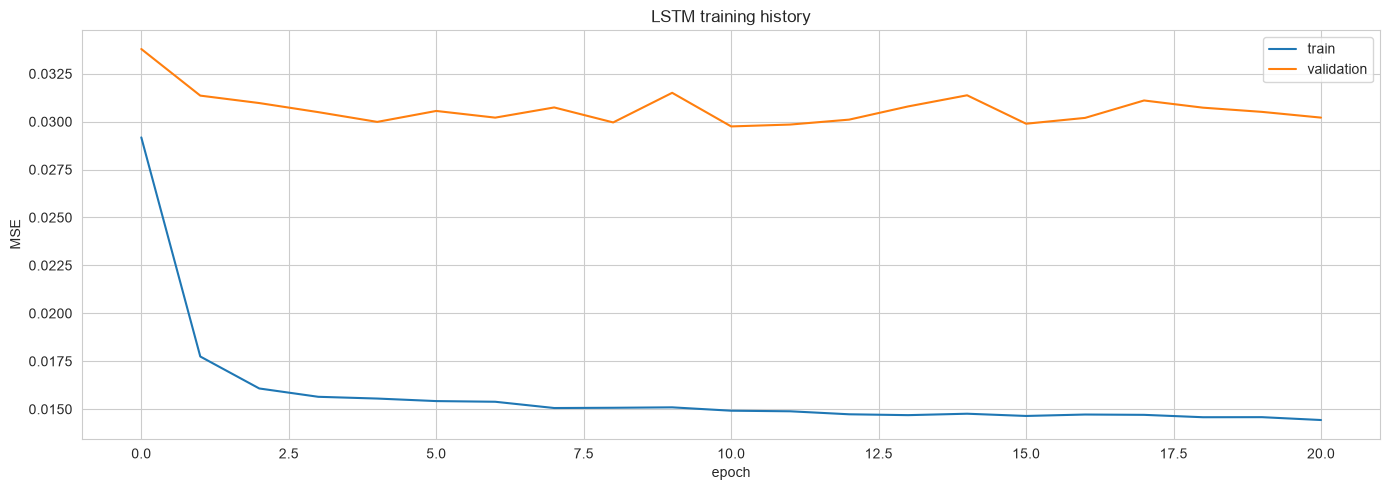

In [117]:
# Score on Nairobi maize so it's comparable to everything else
y_nm = (df_merged[(df_merged['commodity']=='Maize') &
                  (df_merged['market']=='Nairobi') &
                  (df_merged['pricetype']=='Wholesale')]
        .sort_values('date')['price_per_kg'].dropna().values)

sc = MinMaxScaler()
nm_scaled = sc.fit_transform(y_nm.reshape(-1,1)).flatten()
X_nm, y_nm_seq = create_sequences(nm_scaled, window=12)

pred = model_lstm.predict(X_nm[-12:].reshape(-1,12,1), verbose=0)
pred_kes = sc.inverse_transform(pred).flatten()
actual_kes = sc.inverse_transform(y_nm_seq[-12:].reshape(-1,1)).flatten()

mape_lstm = np.mean(np.abs((actual_kes - pred_kes)/actual_kes))*100

print(f'LSTM     {mape_lstm:.2f}%')
print(f'CNN      8.98%')
print(f'Prophet  12.10%')
print(f'Chronos  11.50%')

# Overfitting check — this is the part worth showing
plt.plot(hist_lstm.history['loss'], label='train')
plt.plot(hist_lstm.history['val_loss'], label='validation')
plt.title('LSTM training history')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

In [118]:
# Where does Nairobi Maize sit relative to the split?
offset = 0
nm_range = None
for (commodity, market), group in df_merged.groupby(['commodity','market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 13:
        continue
    n_seq = len(s) - 12
    if commodity == 'Maize' and market == 'Nairobi':
        nm_range = (offset, offset + n_seq)
    offset += n_seq

print(f'Total sequences : {offset:,}')
print(f'Split index     : {split:,}')
print(f'Nairobi Maize   : rows {nm_range[0]:,} to {nm_range[1]:,}')
print()
if nm_range[1] <= split:
    print('Nairobi Maize is entirely in TRAIN — the 8.11% is in-sample.')
elif nm_range[0] >= split:
    print('Nairobi Maize is entirely in TEST — the figure is valid.')
else:
    print('Nairobi Maize straddles the split — partially in-sample.')

Total sequences : 16,016
Split index     : 12,812
Nairobi Maize   : rows 7,821 to 7,999

Nairobi Maize is entirely in TRAIN — the 8.11% is in-sample.


In [119]:
pred_te = model_lstm.predict(X_te, verbose=0).flatten()
mae_lstm = mean_absolute_error(y_te, pred_te)
rmse_lstm = np.sqrt(mean_squared_error(y_te, pred_te))

print('Held-out (scaled 0–1), pooled models only')
print(f'LSTM  MAE {mae_lstm:.4f}  RMSE {rmse_lstm:.4f}')
print(f'CNN   MAE 0.1279  RMSE 0.1882')

Held-out (scaled 0–1), pooled models only
LSTM  MAE 0.1219  RMSE 0.1804
CNN   MAE 0.1279  RMSE 0.1882


In [120]:
# Find which series sit entirely in the held-out portion
offset = 0
test_series = []
for (commodity, market), group in df_merged.groupby(['commodity','market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 13:
        continue
    n_seq = len(s) - 12
    if offset >= split:                      # entirely after the cut
        test_series.append((commodity, market, offset, offset + n_seq))
    offset += n_seq

# Keep only ones your pipeline also modelled
pipeline_keys = {(r['commodity'], r['market']) for _, r in sel_df.iterrows()}
usable = [t for t in test_series if (t[0], t[1]) in pipeline_keys]

print(f'{len(usable)} series held out and also in the pipeline:')
for c, mk, a, b in usable:
    print(f'  {c:14s} {mk:10s}  ({b-a} sequences)')

3 series held out and also in the pipeline:
  Sorghum        Eldoret     (93 sequences)
  Sorghum        Kisumu      (149 sequences)
  Sorghum        Nairobi     (157 sequences)


In [121]:
for c, mk, a, b in usable:
    s = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk)]
         .sort_values('date')['price_per_kg'].dropna().values.astype(float))

    sc = MinMaxScaler()
    s_scaled = sc.fit_transform(s.reshape(-1,1)).flatten()
    Xs, ys = create_sequences(s_scaled, window=12)

    pred = model_lstm.predict(Xs[-12:].reshape(-1,12,1), verbose=0)
    pred_kes = sc.inverse_transform(pred).flatten()
    actual_kes = sc.inverse_transform(ys[-12:].reshape(-1,1)).flatten()

    mape_l = np.mean(np.abs((actual_kes - pred_kes)/actual_kes))*100
    row = sel_df[(sel_df['commodity']==c) & (sel_df['market']==mk)]
    pipe = row.iloc[0]['test_mape'] if len(row) else np.nan
    picked = row.iloc[0]['selected_model'] if len(row) else '—'

    print(f'{c:14s}|{mk:10s}| LSTM {mape_l:5.1f}% | pipeline {pipe:5.1f}% ({picked})')

Sorghum       |Eldoret   | LSTM   5.3% | pipeline   4.8% (chronos)
Sorghum       |Kisumu    | LSTM   5.3% | pipeline  23.4% (prophet)
Sorghum       |Nairobi   | LSTM   7.9% | pipeline  33.5% (chronos)


In [122]:
for c, mk, a, b in usable:
    print(f'{c:14s} {mk:10s} rows {a:,}–{b:,}   split at {split:,}   '
          f'{"held out" if a >= split else "OVERLAPS TRAIN"}')

Sorghum        Eldoret    rows 14,066–14,159   split at 12,812   held out
Sorghum        Kisumu     rows 14,287–14,436   split at 12,812   held out
Sorghum        Nairobi    rows 14,583–14,740   split at 12,812   held out


In [125]:
# Rebuild pooled sequences, holding out the last 12 months of EVERY series
Xtr_l, ytr_l, series_index = [], [], {}
Xte_l, yte_l = {}, {}

for (commodity, market), group in df_merged.groupby(['commodity','market']):
    s = group.sort_values('date')['price_per_kg'].dropna().values.astype(float)
    if len(s) < 40:
        continue
    sc = MinMaxScaler()
    ss = sc.fit_transform(s.reshape(-1,1)).flatten()
    Xs, ys = create_sequences(ss, window=12)
    if len(Xs) < 24:
        continue

    Xtr_l.append(Xs[:-12]); ytr_l.append(ys[:-12])
    Xte_l[(commodity, market)] = (Xs[-12:], ys[-12:], sc)

X_pool = np.vstack(Xtr_l).reshape(-1, 12, 1)
y_pool = np.concatenate(ytr_l)
print(f'{len(X_pool):,} training sequences | {len(Xte_l)} series with clean holdout')

11,194 training sequences | 186 series with clean holdout


Parameters : 4,897
Epochs run : 15
Final train loss      : 0.0120
Final validation loss : 0.0238


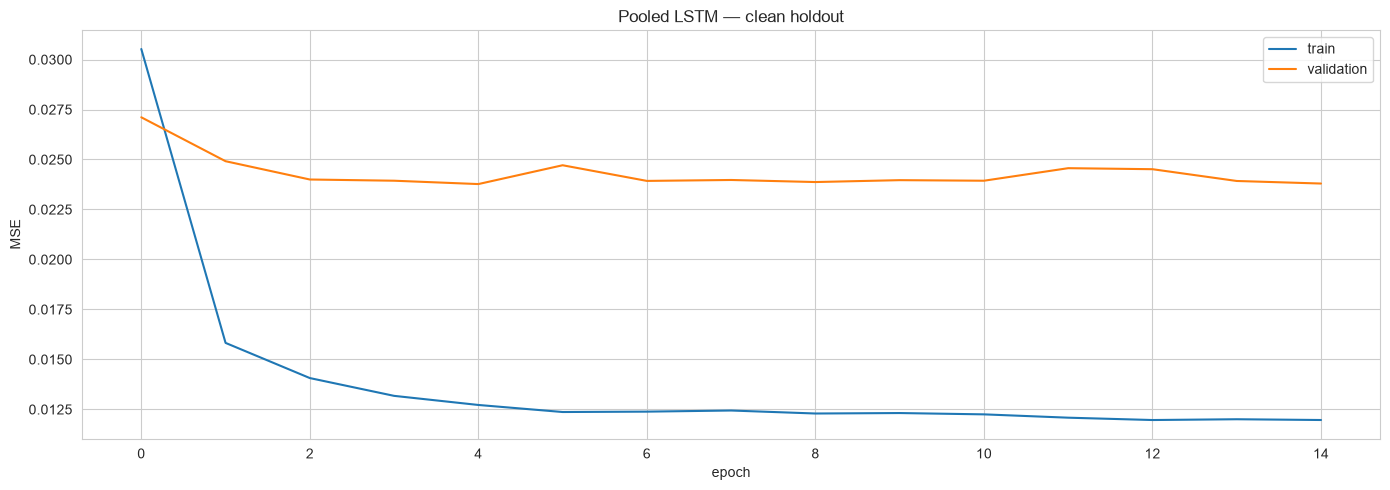

In [126]:
# ── RETRAIN POOLED LSTM WITH CLEAN PER-SERIES HOLDOUT ────────────
model_lstm2 = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm2.compile(optimizer='adam', loss='mse')

hist2 = model_lstm2.fit(
    X_pool, y_pool,
    epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=0
)

print(f'Parameters : {model_lstm2.count_params():,}')
print(f'Epochs run : {len(hist2.history["loss"])}')
print(f'Final train loss      : {hist2.history["loss"][-1]:.4f}')
print(f'Final validation loss : {hist2.history["val_loss"][-1]:.4f}')

plt.plot(hist2.history['loss'], label='train')
plt.plot(hist2.history['val_loss'], label='validation')
plt.title('Pooled LSTM — clean holdout')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout(); plt.show()

In [127]:
# ── LSTM vs PIPELINE ON EVERY SERIES ─────────────────────────────
lstm_vs_pipeline = []

for _, row in sel_df.iterrows():
    c, mk = row['commodity'], row['market']
    if (c, mk) not in Xte_l:
        continue

    Xs_te, ys_te, sc = Xte_l[(c, mk)]
    pred = model_lstm2.predict(Xs_te.reshape(-1, 12, 1), verbose=0)

    pred_kes   = sc.inverse_transform(pred).flatten()
    actual_kes = sc.inverse_transform(ys_te.reshape(-1, 1)).flatten()
    mape_l = float(np.mean(np.abs((actual_kes - pred_kes) / actual_kes)) * 100)

    # volatility of the series, for the pattern check
    s = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk)]
         .sort_values('date')['price_per_kg'].dropna().values)
    cv = float(np.std(s) / np.mean(s) * 100)

    lstm_vs_pipeline.append({
        'commodity': c, 'market': mk, 'pricetype': row['pricetype'],
        'cv_pct': round(cv, 1),
        'lstm_mape': round(mape_l, 2),
        'pipeline_mape': row['test_mape'],
        'pipeline_model': row['selected_model'],
        'lstm_wins': mape_l < row['test_mape']
    })

lvp = pd.DataFrame(lstm_vs_pipeline).sort_values('cv_pct', ascending=False)

print(f'Series compared : {len(lvp)}')
print(f'LSTM wins       : {lvp["lstm_wins"].sum()}/{len(lvp)}')
print(f'Median LSTM     : {lvp["lstm_mape"].median():.2f}%')
print(f'Median pipeline : {lvp["pipeline_mape"].median():.2f}%')

print('\n=== BY COMMODITY ===')
print(lvp.groupby('commodity').agg(
    n=('lstm_mape','count'),
    lstm=('lstm_mape','median'),
    pipeline=('pipeline_mape','median'),
    lstm_wins=('lstm_wins','sum')
).round(2).to_string())

print('\n=== SORTED BY SERIES VOLATILITY ===')
print(lvp[['commodity','market','cv_pct','lstm_mape','pipeline_mape',
           'pipeline_model','lstm_wins']].to_string(index=False))

Series compared : 27
LSTM wins       : 21/27
Median LSTM     : 6.64%
Median pipeline : 9.34%

=== BY COMMODITY ===
                n  lstm  pipeline  lstm_wins
commodity                                   
Beans           4  7.38     11.64          4
Beans (dry)     5  7.97      7.71          3
Beans (mixed)   3  3.04      9.91          3
Maize          11  6.39      7.48          8
Maize meal      1  4.13     12.98          1
Sorghum         3  5.77     23.40          2

=== SORTED BY SERIES VOLATILITY ===
    commodity   market  cv_pct  lstm_mape  pipeline_mape pipeline_model  lstm_wins
      Sorghum  Eldoret    45.9       5.77           4.84        chronos      False
        Maize    Kitui    39.1       4.97           4.92         sarima      False
  Beans (dry)   Nakuru    38.4       6.64           3.32         sarima      False
        Maize     Meru    38.2       6.77           8.52        chronos       True
  Beans (dry)  Eldoret    36.9       6.82           7.71        chronos  

In [128]:
# Does the LSTM advantage come from cross-series temporal leakage?
# Retrain holding out the last 12 months by DATE across all series simultaneously

cutoff = df_merged['date'].max() - pd.DateOffset(months=12)

Xtr_c, ytr_c = [], []
Xte_c = {}

for (commodity, market), group in df_merged.groupby(['commodity','market']):
    g = group.sort_values('date')
    s_all = g['price_per_kg'].dropna()
    if len(s_all) < 40:
        continue
    sc = MinMaxScaler()
    ss = sc.fit_transform(s_all.values.reshape(-1,1)).flatten()
    Xs, ys = create_sequences(ss, window=12)
    if len(Xs) < 24:
        continue

    # index of each target within the original series
    dates = g.loc[s_all.index, 'date'].values[12:]
    is_train = dates < np.datetime64(cutoff)

    Xtr_c.append(Xs[is_train]); ytr_c.append(ys[is_train])
    if (~is_train).sum() >= 6:
        Xte_c[(commodity, market)] = (Xs[~is_train], ys[~is_train], sc)

X_c = np.vstack(Xtr_c).reshape(-1,12,1)
y_c = np.concatenate(ytr_c)
print(f'{len(X_c):,} train sequences, all before {cutoff:%b %Y} | {len(Xte_c)} test series')

12,058 train sequences, all before Aug 2025 | 142 test series


In [129]:
model_lstm3 = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model_lstm3.compile(optimizer='adam', loss='mse')

hist3 = model_lstm3.fit(
    X_c, y_c,
    epochs=100, batch_size=32, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)],
    verbose=0
)
print(f'Epochs {len(hist3.history["loss"])} | '
      f'train {hist3.history["loss"][-1]:.4f} | val {hist3.history["val_loss"][-1]:.4f}')

Epochs 23 | train 0.0125 | val 0.0239


In [130]:
clean_cmp = []

for _, row in sel_df.iterrows():
    c, mk = row['commodity'], row['market']
    if (c, mk) not in Xte_c:
        continue

    Xs_te, ys_te, sc = Xte_c[(c, mk)]
    pred = model_lstm3.predict(Xs_te.reshape(-1,12,1), verbose=0)
    pred_kes   = sc.inverse_transform(pred).flatten()
    actual_kes = sc.inverse_transform(ys_te.reshape(-1,1)).flatten()
    mape_l = float(np.mean(np.abs((actual_kes - pred_kes)/actual_kes))*100)

    clean_cmp.append({
        'commodity': c, 'market': mk,
        'n_test': len(ys_te),
        'lstm_mape': round(mape_l, 2),
        'pipeline_mape': row['test_mape'],
        'pipeline_model': row['selected_model'],
        'lstm_wins': mape_l < row['test_mape']
    })

cc = pd.DataFrame(clean_cmp)

print(f'Series compared : {len(cc)}')
print(f'LSTM wins       : {cc["lstm_wins"].sum()}/{len(cc)}')
print(f'Median LSTM     : {cc["lstm_mape"].median():.2f}%')
print(f'Median pipeline : {cc["pipeline_mape"].median():.2f}%')
print()
print('Previous run (per-series holdout): LSTM 6.64% | wins 21/27')
print()
print(cc.groupby('commodity').agg(
    n=('lstm_mape','count'), lstm=('lstm_mape','median'),
    pipeline=('pipeline_mape','median'), wins=('lstm_wins','sum')
).round(2).to_string())

Series compared : 12
LSTM wins       : 7/12
Median LSTM     : 6.11%
Median pipeline : 6.91%

Previous run (per-series holdout): LSTM 6.64% | wins 21/27

               n  lstm  pipeline  wins
commodity                             
Beans (dry)    1  7.23      3.32     0
Beans (mixed)  3  3.93      9.91     3
Maize          7  6.45      6.34     3
Maize meal     1  5.68     12.98     1


In [131]:
# ── ENSEMBLE vs SELECTION ────────────────────────────────────────
# Does averaging the three models beat picking one per series?

ensemble_results = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    tv, test_y = y[:-12], y[-12:]
    cps = commodity_params[c]

    preds = {}
    try:
        preds['prophet'] = eval_prophet(tv, 12, cps)
    except Exception:
        pass
    s = eval_sarima(tv, 12)
    if s is not None:
        preds['sarima'] = s
    try:
        preds['chronos'] = chronos_forecast(tv, 12)
    except Exception:
        pass

    if len(preds) < 2:
        continue

    stacked = np.vstack(list(preds.values()))
    simple_avg = stacked.mean(axis=0)
    median_avg = np.median(stacked, axis=0)

    ensemble_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'n_models': len(preds),
        'selected_model': row['selected_model'],
        'selected_mape': row['test_mape'],
        'mean_ens_mape':   round(mape(test_y, simple_avg), 2),
        'median_ens_mape': round(mape(test_y, median_avg), 2),
    })

    print(f"{c:14s}|{mk:10s}| selected {row['test_mape']:5.1f}% ({row['selected_model']:7s}) | "
          f"mean {mape(test_y, simple_avg):5.1f}% | median {mape(test_y, median_avg):5.1f}%")

ens_df = pd.DataFrame(ensemble_results)

print('\n' + '='*66)
print(f'Series compared        : {len(ens_df)}')
print(f'Median — selection     : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble : {ens_df["mean_ens_mape"].median():.2f}%')
print(f'Median — median ensemble: {ens_df["median_ens_mape"].median():.2f}%')
print()
print(f'Mean ensemble beats selection on   {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print(f'Median ensemble beats selection on {(ens_df["median_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print()
print('=== BY COMMODITY ===')
print(ens_df.groupby('commodity')[['selected_mape','mean_ens_mape','median_ens_mape']]
      .median().round(2).to_string())


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 12 and the array at index 2 has size 1

In [132]:
ensemble_results = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    tv, test_y = y[:-12], y[-12:]
    cps = commodity_params[c]

    preds = {}
    try:
        p = np.asarray(eval_prophet(tv, 12, cps)).ravel()
        if p.shape == (12,): preds['prophet'] = p
    except Exception:
        pass

    s = eval_sarima(tv, 12)
    if s is not None:
        s = np.asarray(s).ravel()
        if s.shape == (12,): preds['sarima'] = s

    try:
        ch = np.asarray(chronos_forecast(tv, 12)).ravel()
        if ch.shape == (12,): preds['chronos'] = ch
    except Exception:
        pass

    if len(preds) < 2:
        print(f'{c:14s}|{mk:10s}| skipped — only {len(preds)} usable model(s)')
        continue

    stacked = np.vstack([preds[k] for k in preds])
    simple_avg = stacked.mean(axis=0)
    median_avg = np.median(stacked, axis=0)

    ensemble_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'n_models': len(preds),
        'selected_model': row['selected_model'],
        'selected_mape': row['test_mape'],
        'mean_ens_mape':   round(mape(test_y, simple_avg), 2),
        'median_ens_mape': round(mape(test_y, median_avg), 2),
    })

    print(f"{c:14s}|{mk:10s}| selected {row['test_mape']:5.1f}% ({row['selected_model']:7s}) | "
          f"mean {mape(test_y, simple_avg):5.1f}% | median {mape(test_y, median_avg):5.1f}%")

ens_df = pd.DataFrame(ensemble_results)

print('\n' + '='*66)
print(f'Series compared          : {len(ens_df)}')
print(f'Median — selection       : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble   : {ens_df["mean_ens_mape"].median():.2f}%')
print(f'Median — median ensemble : {ens_df["median_ens_mape"].median():.2f}%')
print()
print(f'Mean ensemble wins   {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print(f'Median ensemble wins {(ens_df["median_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print()
print(ens_df.groupby('commodity')[['selected_mape','mean_ens_mape','median_ens_mape']]
      .median().round(2).to_string())

Maize         |Nairobi   | selected   9.3% (chronos) | mean  12.0% | median  12.0%
Maize         |Nakuru    | selected   7.1% (chronos) | mean  10.3% | median  10.3%
Maize         |Mombasa   | selected  13.3% (prophet) | mean  15.6% | median  15.6%
Maize         |Kisumu    | selected  22.5% (chronos) | mean  17.7% | median  17.7%
Maize         |Kitui     | selected   4.9% (sarima ) | mean   6.1% | median   6.1%
Maize         |Meru      | selected   8.5% (chronos) | mean   7.9% | median   7.9%
Maize         |Makueni   | selected   2.2% (sarima ) | mean   2.6% | median   2.6%
Maize         |Wajir     | selected   7.5% (chronos) | mean   6.6% | median   6.6%
Maize         |Mandera   | selected  12.6% (prophet) | mean  10.6% | median  10.6%
Maize         |Marsabit  | selected   5.3% (sarima ) | mean   7.5% | median   7.5%
Maize         |Isiolo    | selected   6.3% (sarima ) | mean   6.0% | median   6.0%
Beans         |Nairobi   | selected  10.7% (chronos) | mean  14.8% | median  14.8%
Bean

In [133]:
print(f'Series compared          : {len(ens_df)}')
print(f'Median — selection       : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble   : {ens_df["mean_ens_mape"].median():.2f}%')
print()
print(f'Ensemble wins {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print(f'Mean absolute gap: {(ens_df["mean_ens_mape"] - ens_df["selected_mape"]).abs().mean():.2f} points')

Series compared          : 27
Median — selection       : 9.34%
Median — mean ensemble   : 10.55%

Ensemble wins 14/27
Mean absolute gap: 3.79 points


In [134]:
print(ens_df['n_models'].value_counts().to_string())

n_models
2    27


In [135]:
y = (df_merged[(df_merged['commodity']=='Maize') & (df_merged['market']=='Nairobi') &
               (df_merged['pricetype']=='Wholesale')]
     .sort_values('date')['price_per_kg'].dropna().values)
tv = y[:-12]

for name, fn in [('prophet', lambda: eval_prophet(tv, 12, 0.10)),
                 ('sarima',  lambda: eval_sarima(tv, 12)),
                 ('chronos', lambda: chronos_forecast(tv, 12))]:
    try:
        out = fn()
        arr = np.asarray(out).ravel() if out is not None else None
        print(f'{name:8s} -> {"None" if arr is None else arr.shape}')
    except Exception as e:
        print(f'{name:8s} -> EXCEPTION: {type(e).__name__}: {e}')
        

prophet  -> (12,)
sarima   -> (12,)
chronos  -> (1,)


In [136]:
s = eval_sarima(tv, 12)
print('sarima  ->', 'None' if s is None else np.asarray(s).ravel().shape)

sarima  -> (12,)


In [137]:
ch = chronos_forecast(tv, 12)
print('chronos ->', np.asarray(ch).ravel().shape)

chronos -> (1,)


In [139]:
ctx = torch.tensor(np.asarray(tv, dtype=np.float32))
raw = pipeline.predict(ctx, prediction_length=12, num_samples=50)
print('type      :', type(raw))
print('raw[0]    :', np.asarray(raw[0]).shape)

type      : <class 'torch.Tensor'>
raw[0]    : (50, 12)


In [140]:
import inspect
print(inspect.getsource(chronos_forecast))

def chronos_forecast(train_values, horizon=12, n_samples=50):
    """Zero-shot forecast — no training."""
    context = torch.tensor(np.asarray(train_values, dtype=np.float32))
    fc = pipeline.predict(context, prediction_length=horizon, num_samples=n_samples)
    arr = fc[0].numpy()
    return {
        'median': np.quantile(arr, 0.5, axis=0),
        'lower':  np.quantile(arr, 0.1, axis=0),
        'upper':  np.quantile(arr, 0.9, axis=0),
    }



In [141]:
def chronos_forecast(train_values, horizon=12, n_samples=50):
    ctx = torch.tensor(np.asarray(train_values, dtype=np.float32))
    arr = pipeline.predict(ctx, prediction_length=horizon,
                           num_samples=n_samples)[0].numpy()
    return np.quantile(arr, 0.5, axis=0)

# verify
out = chronos_forecast(tv, 12)
print('shape:', np.asarray(out).shape)   # expect (12,)

shape: (12,)


In [142]:
ensemble_results = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    y = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)]
         .sort_values('date')['price_per_kg'].dropna().values)
    if len(y) < 84:
        continue

    tv, test_y = y[:-12], y[-12:]
    cps = commodity_params[c]

    preds = {}
    try:
        p = np.asarray(eval_prophet(tv, 12, cps)).ravel()
        if p.shape == (12,): preds['prophet'] = p
    except Exception:
        pass

    s = eval_sarima(tv, 12)
    if s is not None:
        s = np.asarray(s).ravel()
        if s.shape == (12,): preds['sarima'] = s

    try:
        ch = np.asarray(chronos_forecast(tv, 12)).ravel()
        if ch.shape == (12,): preds['chronos'] = ch
    except Exception:
        pass

    if len(preds) < 2:
        print(f'{c:14s}|{mk:10s}| skipped — only {len(preds)} usable model(s)')
        continue

    stacked = np.vstack([preds[k] for k in preds])
    simple_avg = stacked.mean(axis=0)
    median_avg = np.median(stacked, axis=0)

    ensemble_results.append({
        'commodity': c, 'market': mk, 'pricetype': pt,
        'n_models': len(preds),
        'selected_model': row['selected_model'],
        'selected_mape': row['test_mape'],
        'mean_ens_mape':   round(mape(test_y, simple_avg), 2),
        'median_ens_mape': round(mape(test_y, median_avg), 2),
    })

    print(f"{c:14s}|{mk:10s}| selected {row['test_mape']:5.1f}% ({row['selected_model']:7s}) | "
          f"mean {mape(test_y, simple_avg):5.1f}% | median {mape(test_y, median_avg):5.1f}%")

ens_df = pd.DataFrame(ensemble_results)

print('\n' + '='*66)
print(f'Series compared          : {len(ens_df)}')
print(f'Median — selection       : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble   : {ens_df["mean_ens_mape"].median():.2f}%')
print(f'Median — median ensemble : {ens_df["median_ens_mape"].median():.2f}%')
print()
print(f'Mean ensemble wins   {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print(f'Median ensemble wins {(ens_df["median_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print()
print(ens_df.groupby('commodity')[['selected_mape','mean_ens_mape','median_ens_mape']]
      .median().round(2).to_string())

Maize         |Nairobi   | selected   9.3% (chronos) | mean  11.2% | median  11.1%
Maize         |Nakuru    | selected   7.1% (chronos) | mean   9.6% | median   9.2%
Maize         |Mombasa   | selected  13.3% (prophet) | mean  14.0% | median  13.8%
Maize         |Kisumu    | selected  22.5% (chronos) | mean  19.1% | median  21.1%
Maize         |Kitui     | selected   4.9% (sarima ) | mean   7.1% | median   5.5%
Maize         |Meru      | selected   8.5% (chronos) | mean   7.5% | median   6.8%
Maize         |Makueni   | selected   2.2% (sarima ) | mean   2.1% | median   2.1%
Maize         |Wajir     | selected   7.5% (chronos) | mean   4.1% | median   6.0%
Maize         |Mandera   | selected  12.6% (prophet) | mean   9.4% | median   8.7%
Maize         |Marsabit  | selected   5.3% (sarima ) | mean   5.3% | median   5.2%
Maize         |Isiolo    | selected   6.3% (sarima ) | mean   6.6% | median   6.1%
Beans         |Nairobi   | selected  10.7% (chronos) | mean  13.7% | median  14.2%
Bean

In [143]:
print(ens_df['n_models'].value_counts().to_string())
print()
print(f'Median — selection       : {ens_df["selected_mape"].median():.2f}%')
print(f'Median — mean ensemble   : {ens_df["mean_ens_mape"].median():.2f}%')
print(f'Median — median ensemble : {ens_df["median_ens_mape"].median():.2f}%')
print()
print(f'Mean ens wins   {(ens_df["mean_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')
print(f'Median ens wins {(ens_df["median_ens_mape"] < ens_df["selected_mape"]).sum()}/{len(ens_df)}')

n_models
3    27

Median — selection       : 9.34%
Median — mean ensemble   : 9.56%
Median — median ensemble : 10.41%

Mean ens wins   14/27
Median ens wins 17/27


In [144]:
ENSEMBLE_COMMODITIES = {'Sorghum', 'Maize meal'}
horizons = [3, 6, 12]
final_rows = []

for _, row in sel_df.iterrows():
    c, mk, pt = row['commodity'], row['market'], row['pricetype']

    s = (df_merged[(df_merged['commodity']==c) & (df_merged['market']==mk) &
                   (df_merged['pricetype']==pt)].sort_values('date'))
    y = s['price_per_kg'].dropna().values
    last = pd.Timestamp(s['date'].max()).to_period('M').to_timestamp()
    cps = commodity_params[c]

    use_ensemble = c in ENSEMBLE_COMMODITIES
    strategy = 'ensemble' if use_ensemble else row['selected_model']

    for h in horizons:
        dates = pd.date_range(last + pd.DateOffset(months=1), periods=h, freq='MS')

        if use_ensemble:
            parts = []
            try:
                p = np.asarray(eval_prophet(y, h, cps)).ravel()
                if p.shape == (h,): parts.append(p)
            except Exception: pass
            sa = eval_sarima(y, h)
            if sa is not None:
                sa = np.asarray(sa).ravel()
                if sa.shape == (h,): parts.append(sa)
            try:
                ch = np.asarray(chronos_forecast(y, h)).ravel()
                if ch.shape == (h,): parts.append(ch)
            except Exception: pass
            if not parts:
                continue
            pred = np.mean(parts, axis=0)
            spread = np.std(parts, axis=0) if len(parts) > 1 else np.zeros(h)
            lo, hi = pred - 1.96*spread, pred + 1.96*spread

        elif row['selected_model'] == 'prophet':
            idx = pd.date_range(end=last, periods=len(y), freq='MS')
            m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False,
                        changepoint_prior_scale=cps)
            m.fit(pd.DataFrame({'ds': idx, 'y': y}))
            fc = m.predict(m.make_future_dataframe(periods=h, freq='MS')).tail(h)
            pred, lo, hi = fc['yhat'].values, fc['yhat_lower'].values, fc['yhat_upper'].values

        elif row['selected_model'] == 'sarima':
            best = None
            for p_, q_ in itertools.product([0,1,2],[0,1,2]):
                for P_, Q_ in itertools.product([0,1],[0,1]):
                    try:
                        f = SARIMAX(y, order=(p_,1,q_), seasonal_order=(P_,1,Q_,12),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False).fit(disp=False)
                        if np.isfinite(f.aic) and (best is None or f.aic < best[0]):
                            best = (f.aic, f)
                    except Exception: continue
            if best is None: continue
            res = best[1].get_forecast(steps=h)
            pred = np.asarray(res.predicted_mean)
            ci = np.asarray(res.conf_int())
            lo, hi = ci[:,0], ci[:,1]

        else:  # chronos
            ctx = torch.tensor(np.asarray(y, dtype=np.float32))
            arr = pipeline.predict(ctx, prediction_length=h, num_samples=100)[0].numpy()
            pred = np.quantile(arr, 0.5, axis=0)
            lo   = np.quantile(arr, 0.1, axis=0)
            hi   = np.quantile(arr, 0.9, axis=0)

        for d, p_, l_, h_ in zip(dates, pred, lo, hi):
            final_rows.append({
                'commodity': c, 'market': mk, 'region': row['region'], 'pricetype': pt,
                'strategy': strategy,
                'forecast_date': d, 'horizon_months': h,
                'forecast_price_kes': round(float(p_), 2),
                'forecast_lower': round(float(max(l_, 0)), 2),
                'forecast_upper': round(float(h_), 2),
                'test_mape': row['test_mape'],
            })

    print(f'{c:14s}|{mk:10s}|{pt:9s}| {strategy}')

final_df = pd.DataFrame(final_rows)
final_df['confidence'] = pd.cut(final_df['test_mape'], [0,10,20,1000],
                                labels=['high','medium','low'])

print(f'\n{len(final_df)} forecast rows | {final_df["strategy"].value_counts().to_dict()}')


Maize         |Nairobi   |Wholesale| chronos
Maize         |Nakuru    |Wholesale| chronos
Maize         |Mombasa   |Wholesale| prophet
Maize         |Kisumu    |Wholesale| chronos
Maize         |Kitui     |Retail   | sarima
Maize         |Meru      |Retail   | chronos
Maize         |Makueni   |Retail   | sarima
Maize         |Wajir     |Retail   | chronos
Maize         |Mandera   |Retail   | prophet
Maize         |Marsabit  |Retail   | sarima
Maize         |Isiolo    |Retail   | sarima
Beans         |Nairobi   |Wholesale| chronos
Beans         |Nakuru    |Wholesale| prophet
Beans         |Kisumu    |Wholesale| chronos
Beans         |Eldoret   |Wholesale| chronos
Beans (dry)   |Nairobi   |Wholesale| chronos
Beans (dry)   |Nakuru    |Retail   | sarima
Beans (dry)   |Kisumu    |Wholesale| prophet
Beans (dry)   |Kitui     |Retail   | sarima
Beans (dry)   |Eldoret   |Wholesale| chronos
Beans (mixed) |Kitui     |Retail   | sarima
Beans (mixed) |Meru      |Retail   | chronos
Beans (mixed) |Ma

In [145]:
# Replace test_mape for ensemble series with their actual ensemble error
ens_lookup = {(r['commodity'], r['market'], r['pricetype']): r['mean_ens_mape']
              for _, r in ens_df.iterrows()}

mask = final_df['strategy'] == 'ensemble'
final_df.loc[mask, 'test_mape'] = final_df.loc[mask].apply(
    lambda r: ens_lookup.get((r['commodity'], r['market'], r['pricetype']), r['test_mape']),
    axis=1)

final_df['confidence'] = pd.cut(final_df['test_mape'], [0, 10, 20, 1000],
                                labels=['high', 'medium', 'low'])

series_view = final_df.drop_duplicates(['commodity','market','pricetype'])
print(series_view['confidence'].value_counts().to_string())
print()
print(f'Median MAPE across served series: {series_view["test_mape"].median():.2f}%')

confidence
high      15
medium     8
low        4

Median MAPE across served series: 9.34%


In [146]:
import joblib, os, json

os.makedirs('../../data/exports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

final_df.to_csv('../../data/exports/production_forecasts.csv', index=False)
sel_df.to_csv('../../data/exports/model_selection.csv', index=False)
ens_df.to_csv('../../data/exports/ensemble_comparison.csv', index=False)
metrics_df.to_csv('../../data/exports/model_metrics.csv', index=False)
anomalies_df.to_csv('../../data/exports/price_anomalies.csv', index=False)

routing = {}
for _, r in series_view.iterrows():
    routing[f"{r['commodity']}|{r['market']}|{r['pricetype']}"] = {
        'strategy': r['strategy'],
        'test_mape': float(r['test_mape']),
        'confidence': str(r['confidence']),
        'region': r['region'],
    }

with open('../../models/model_routing.json', 'w') as f:
    json.dump(routing, f, indent=2)

print(f'{len(final_df)} forecasts | {len(routing)} series routed')
print(final_df.groupby('strategy')['test_mape'].median().round(2).to_string())

567 forecasts | 27 series routed
strategy
chronos      9.34
ensemble    13.09
prophet     13.42
sarima       5.04
